## Ανάλυση Βιο-Δεδομένων - Ομάδα 3
### Synthetic Medical Data Generation: Opportunities and Challenges for GenAI-Based Augmentation

**Βάση Δεδομένων:** Diabetes Health Indicators Dataset  
https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

(Αρχείο: diabetes_012_health_indicators_BRFSS2015.csv)

**Μέλη Ομάδας:**
- 03400305 - Παντελεήμων Ναούμ
- 03400288 - Ανδρέας Γκανάς
- 03400289 - Κερκύρα Δημησίανου

---

#### A. Υπόβαθρο και Κίνητρο

Ο διαβήτης αποτελεί μία από τις πιο διαδεδομένες χρόνιες ασθένειες παγκοσμίως. Τα διαθέσιμα δεδομένα συχνά παρουσιάζουν σοβαρή ανισορροπία κλάσεων, δυσχεραίνοντας την εκπαίδευση αξιόπιστων μοντέλων πρόβλεψης. Η παραγωγή συνθετικών δεδομένων μπορεί να αντιμετωπίσει αυτή την πρόκληση, βελτιώνοντας την ικανότητα γενίκευσης.



#### B. Στόχοι / Ερευνητικά Ερωτήματα

* **Στόχος/Ερώτημα 1:** Μπορούν οι τεχνικές παραγωγής συνθετικών δεδομένων (CTGAN, VAE, SMOTE) να βελτιώσουν την επίδοση ταξινομητών σε ανισόρροπα ιατρικά σύνολα δεδομένων;

* **Στόχος/Ερώτημα 2:** Ποια μέθοδος παραγωγής συνθετικών δεδομένων διατηρεί καλύτερα τις στατιστικές ιδιότητες και τις συσχετίσεις μεταξύ μεταβλητών του αρχικού συνόλου;

* **Στόχος/Ερώτημα 3:** Πώς επηρεάζεται η πρόβλεψη του προ-διαβήτη (κλάση 1) ως μειοψηφούσα κατηγορία μέσω της αύξησης δεδομένων;


#### C. Μεθοδολογία

Θα χρησιμοποιηθεί το αρχείο diabetes_012_health_indicators_BRFSS2015.csv με 3 κλάσεις. Η προεπεξεργασία περιλαμβάνει κανονικοποίηση, ανάλυση ελλιπών τιμών και EDA. Για την παραγωγή συνθετικών δεδομένων θα εφαρμοστούν: SMOTE, CTGAN (βιβλιοθήκη SDV) και ένας απλός Variational Autoencoder (PyTorch). Η αξιολόγηση θα γίνει μέσω εκπαίδευσης ταξινομητών (Random Forest, XGBoost) πριν και μετά την αύξηση. Μετρικές: F1-score (macro), AUC-ROC, precision/recall ανά κλάση. Η ποιότητα των συνθετικών δεδομένων θα ελεγχθεί με στατιστικούς ελέγχους (KS-test) και οπτικοποιήσεις (t-SNE).

Αναμένεται βελτίωση στη ταξινόμηση του προ-διαβήτη μέσω αύξησης δεδομένων, με τις deep generative μεθόδους (CTGAN/VAE) να υπερτερούν του SMOTE στη διατήρηση στατιστικών ιδιοτήτων. Θα παρασχεθεί συγκριτική ανάλυση μεθόδων και συστάσεις.

---


#### 0. Εισαγωγή Βιβλιοθηκών

Αρχικά εισάγουμε όλες τις βιβλιοθήκες οι οποίες θα χρησιμοποιηθούν για το project μας

Αν λείπουν βιβλιοθήκες τις εγκαθιστούμε στο python venv μας:

```bash
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn sdv torch scipy missingno
```

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn sdv torch scipy missingno

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms
import warnings, os, time
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# XGBoost
from xgboost import XGBClassifier

# SMOTE
from imblearn.over_sampling import SMOTE

# CTGAN (SDV)
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# PyTorch (for VAE)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Statistical tests
from scipy.stats import ks_2samp

# Plotting defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ All imports successful.")

✅ All imports successful.


---
# ΜΕΡΟΣ 1 — Εxploratory Data Analysis (EDA)
---

## 1. Φόρτωση Δεδομένων

Αρχικά πραγματοποιείται import των δεδομένων και EDA.

Θα χρησιμοποιηθεί το dataset από το αρχείο `diabetes_012_health_indicators_BRFSS2015.csv`, αφότου το κατεβάσουμε από το kaggle.

Παρακάτω φαίνονται τα πρώτα 5 rows του dataset. Όλες οι στήλες έχουν αριθμητικές τιμές.

In [ ]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset
# Place the CSV in the same directory as this notebook.

DATA_PATH = 'diabetes_012_health_indicators_BRFSS2015.csv'
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}):\n{list(df.columns)}")
df.head()

Shape: (253680, 22)
Columns (22):
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Η στήλη **Diabetes_012** δείχνει την κλάση και δέχεται τιμές:

- **0**: όχι διαβήτης
- **1**: προ-διαβήτης
- **2**: διαβήτης

### 1.1 Βασικές Πληροφορίες Dataset

Το dataset περιέχει τα ακόλουθα features:

| Feature | Περιγραφή |
|---|---|
| **Diabetes_012** | Η κλάση (0=Χωρίς Διαβήτη, 1=Προ-Διαβήτης, 2=Διαβήτης) |
| **HighBP** | 0=χωρίς υψηλή πίεση, 1=υψηλή πίεση |
| **HighChol** | 0=χωρίς υψηλή χοληστερίνη, 1=υψηλή χοληστερίνη |
| **CholCheck** | 0=χωρίς έλεγχο χοληστερίνης τα τελευταία 5 χρόνια, 1=ναι |
| **BMI** | Δείκτης Μάζας Σώματος |
| **Smoker** | ≥100 τσιγάρα σε όλη τη ζωή; 0=όχι, 1=ναι |
| **Stroke** | Εγκεφαλικό επεισόδιο; 0=όχι, 1=ναι |
| **HeartDiseaseorAttack** | Στεφανιαία νόσος ή έμφραγμα; 0=όχι, 1=ναι |
| **PhysActivity** | Φυσική δραστηριότητα τελευταίες 30 μέρες (εκτός εργασίας); 0=όχι, 1=ναι |
| **Fruits** | Κατανάλωση φρούτων ≥1 φορά/μέρα; 0=όχι, 1=ναι |
| **Veggies** | Κατανάλωση λαχανικών ≥1 φορά/μέρα; 0=όχι, 1=ναι |
| **HvyAlcoholConsump** | Υπερβολική κατανάλωση αλκοόλ (>14 ποτά/εβδ. άνδρες, >7 γυναίκες); 0=όχι, 1=ναι |
| **AnyHealthcare** | Κάλυψη υγείας; 0=όχι, 1=ναι |
| **NoDocbcCost** | Αδυναμία επίσκεψης σε γιατρό λόγω κόστους (τελευταίοι 12 μήνες); 0=όχι, 1=ναι |
| **GenHlth** | Γενική υγεία κλίμακα 1–5 (1=άριστη, 5=κακή) |
| **MentHlth** | Μέρες κακής ψυχικής υγείας τελευταίες 30 μέρες (0–30) |
| **PhysHlth** | Μέρες κακής σωματικής υγείας τελευταίες 30 μέρες (0–30) |
| **DiffWalk** | Σοβαρή δυσκολία βαδίσματος/σκαλοπατιών; 0=όχι, 1=ναι |
| **Sex** | 0=γυναίκα, 1=άνδρας |
| **Age** | Κατηγορία ηλικίας 13 επιπέδων (1=18–24, 13=80+) |
| **Education** | Επίπεδο εκπαίδευσης κλίμακα 1–6 |
| **Income** | Κλίμακα εισοδήματος 1–8 (1=<$10k, 8=$75k+) |

Κοιτώντας το είδος από κάθε feature, βλέπουμε πως όλες οι στήλες έχουν Dtype float64. Επιπλέον, όλα έχουν 253680 non-null values, εφόσον ο συνολικός αριθμός γραμμών είναι 253680, δεν υπάρχουν missing values στο dataset. Αυτό είναι αναμενόμενο καθώς το dataset ήταν ήδη cleaned.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

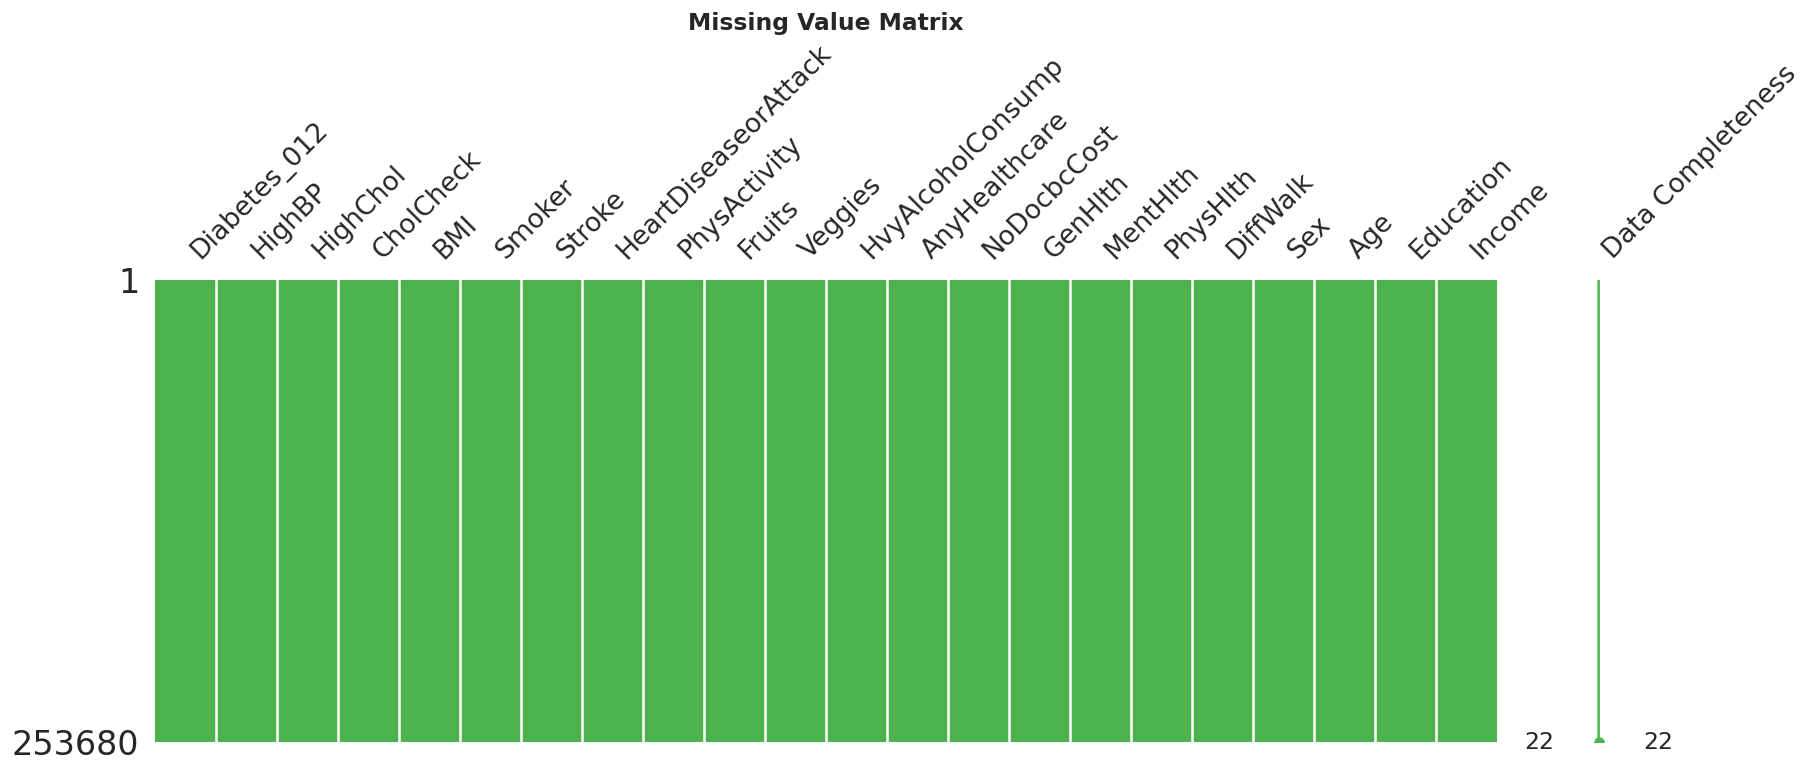

In [ ]:
ms.matrix(df, figsize=(16, 5), color=(0.3, 0.7, 0.3), labels=True)
plt.title('Missing Value Matrix', fontsize=14, fontweight='bold')
plt.show()

Επίσης, εκτυπώνοντας στατιστικά για το dataset βλέπουμε για κάθε feature το mean, standard deviation, min, 25% percentatile, median, 75% percentile και max.

- Από τα independent variables, τα features <b>ΒΜΙ, MentHealth</b> και <b>PhysHlth</b> είναι numeric. Επειδή εχουν διαφορετικές κλίμακες, θα χρειαστεί αργότερα να πραγματοποιήσουμε standardization.

- Οι μεταβλητές <b>GenHlth</b>, <b>Age</b>, <b>Education</b>, <b>Income</b> αποτελούν κατηγορηματικές μεταβλητές με πάνω από 2 κατηγορίες. Πιθανώς στην συνέχεια να χρειαστεί να δημιουργήσουμε dummy variables αν χρησιμοποιήσουμε κάποιο ταξινομητή όπως logistic regression.

- Οι υπόλοιπες μεταβλητές είναι binary categorical variables.

In [ ]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.30,0.70,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.43,0.49,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.42,0.49,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.96,0.19,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.38,6.61,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.44,0.50,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.04,0.20,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.09,0.29,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.76,0.43,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.63,0.48,0.0,0.0,1.0,1.0,1.0


Παρακάτω βλέπουμε ιστογράμματα για κάθε μεταβλητή. Παρατηρούμε πως:

- Ελάχιστα άτομα δεν έχουν ελέγξει την χοληστερίνη τα τελευταία 5 χρόνια.
- Ελάχιστα άτομα έχουν περάσει εγκεφαλικό επεισόδιο.
- Ελάχιστα άτομα έχουν coronary heart disease (CHD) ή myocardial infarction (MI).
- Λίγα άτομα δεν καταναλώνουν λαχανικά.
- Ελάχιστα άτομα καταναλώνουν πολύ αλκόολ.
- Ελάχιστα άτομα δεν έχουν κάλυψη για την υγεία.
- Ελάχιστα άτομα δεν έχουν λεφτά για να πάνε στο γιατρό.
- Λίγα άτομα έχουν δυσκολία να περπατήσουν.

Από τα independent variables, τα features **BMI**, **MentHlth** και **PhysHlth** είναι numeric — λόγω διαφορετικών κλιμάκων απαιτείται standardization. Οι μεταβλητές **GenHlth**, **Age**, **Education**, **Income** αποτελούν κατηγορηματικές μεταβλητές με πάνω από 2 κατηγορίες. Οι υπόλοιπες είναι binary categorical.

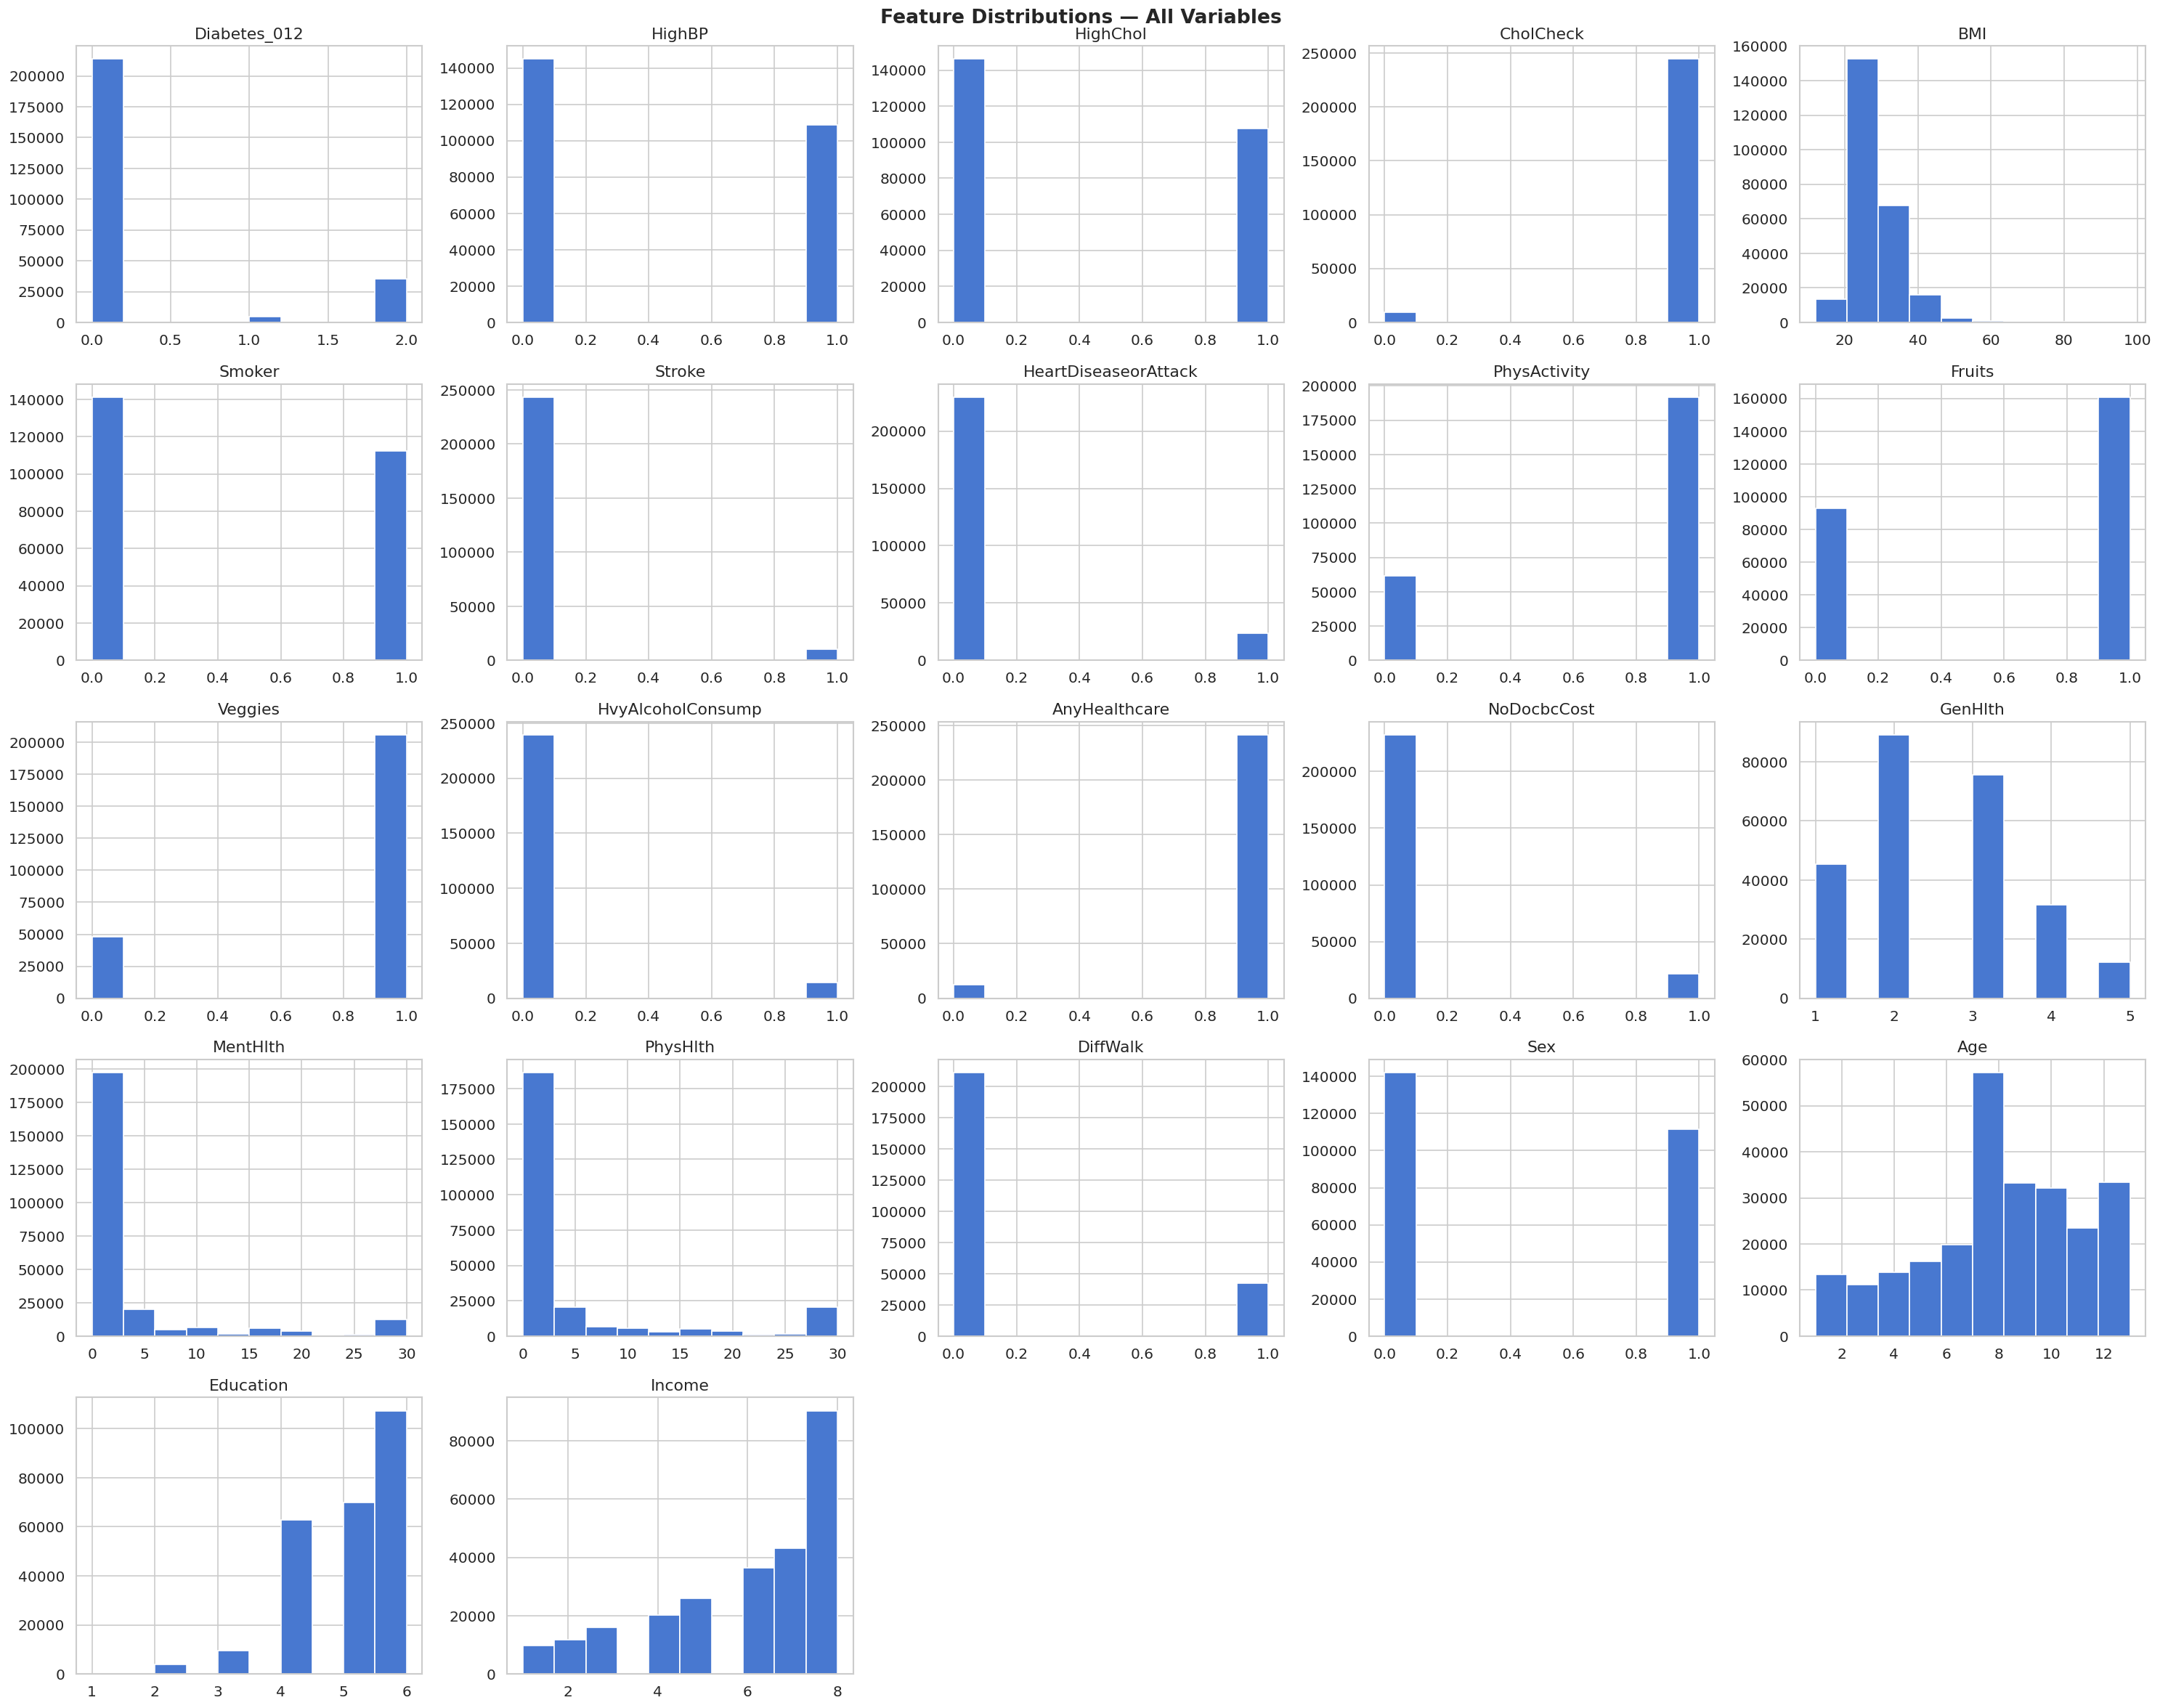

In [ ]:
fig = plt.figure(figsize=(25, 20))
ax = fig.gca()
df.hist(ax=ax)
plt.suptitle('Feature Distributions — All Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Missing values
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
missing[missing > 0]

Total missing values: 0


,0


### 1.2 Κατανομή Μεταβλητής Στόχου

Παρακάτω βλέπουμε στα plots πόσοι patients ανήκουν σε κάθε κλάση. Τα δεδομένα είναι unbalanced.

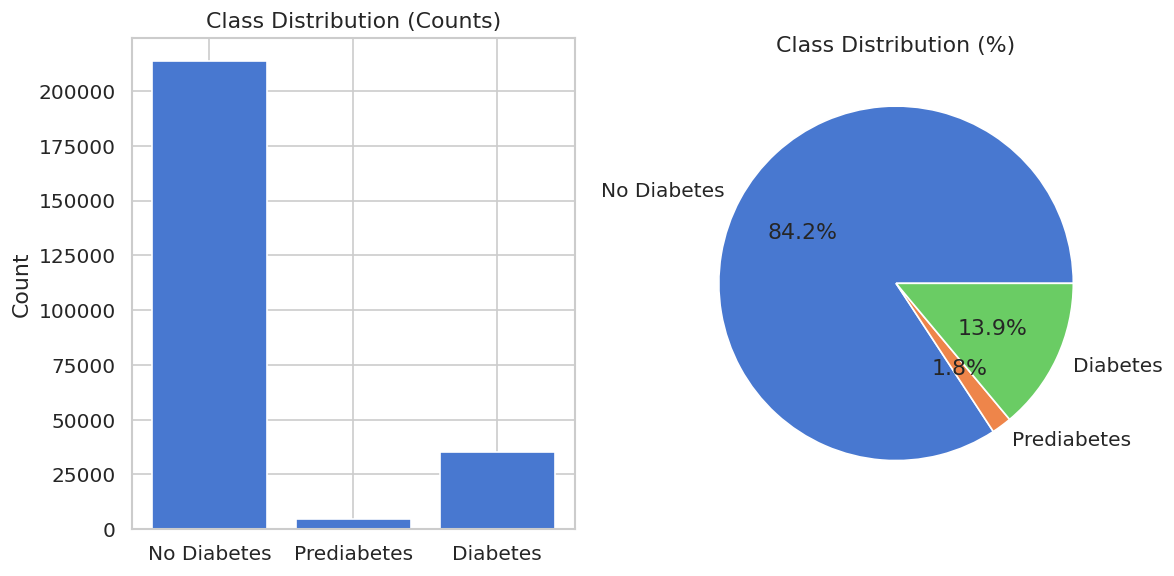

Class 0 (No Diabetes): 213703 (84.24%)
Class 1 (Prediabetes): 4631 (1.83%)
Class 2 (Diabetes): 35346 (13.93%)

Imbalance ratio (Class 0 / Class 1): 46.1x


In [ ]:
class_map = {0: 'No Diabetes', 1: 'Prediabetes', 2: 'Diabetes'}
target_counts = df['Diabetes_012'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2)

# Bar chart
axes[0].bar(target_counts.index.map(class_map), target_counts.values)
axes[0].set_title('Class Distribution (Counts)')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=[class_map[i] for i in target_counts.index],
    autopct='%1.1f%%'
)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

# Imbalance ratios
for cls in [0, 1, 2]:
    print(f"Class {cls} ({class_map[cls]}): {target_counts[cls]} "
          f"({target_counts[cls] / len(df) * 100:.2f}%)")

print(f"\nImbalance ratio (Class 0 / Class 1): {target_counts[0] / target_counts[1]:.1f}x")

### 1.3 Ανάλυση Συσχετίσεων

Παρακάτω φαίνονται οι συσχετίσεις των μεταβλητών. Η κλάση (**Diabetes_012**) δεν έχει μεγάλη συσχέτιση με κάποια συγκεκριμένη στήλη, αλλά εμφανίζει μικρή συσχέτιση με την **γενική υγεία (GenHlth)**, την **υψηλή πίεση (HighBP)**, την **χοληστερίνη (HighChol)**, το **BMI** και την **ηλικία (Age)**.

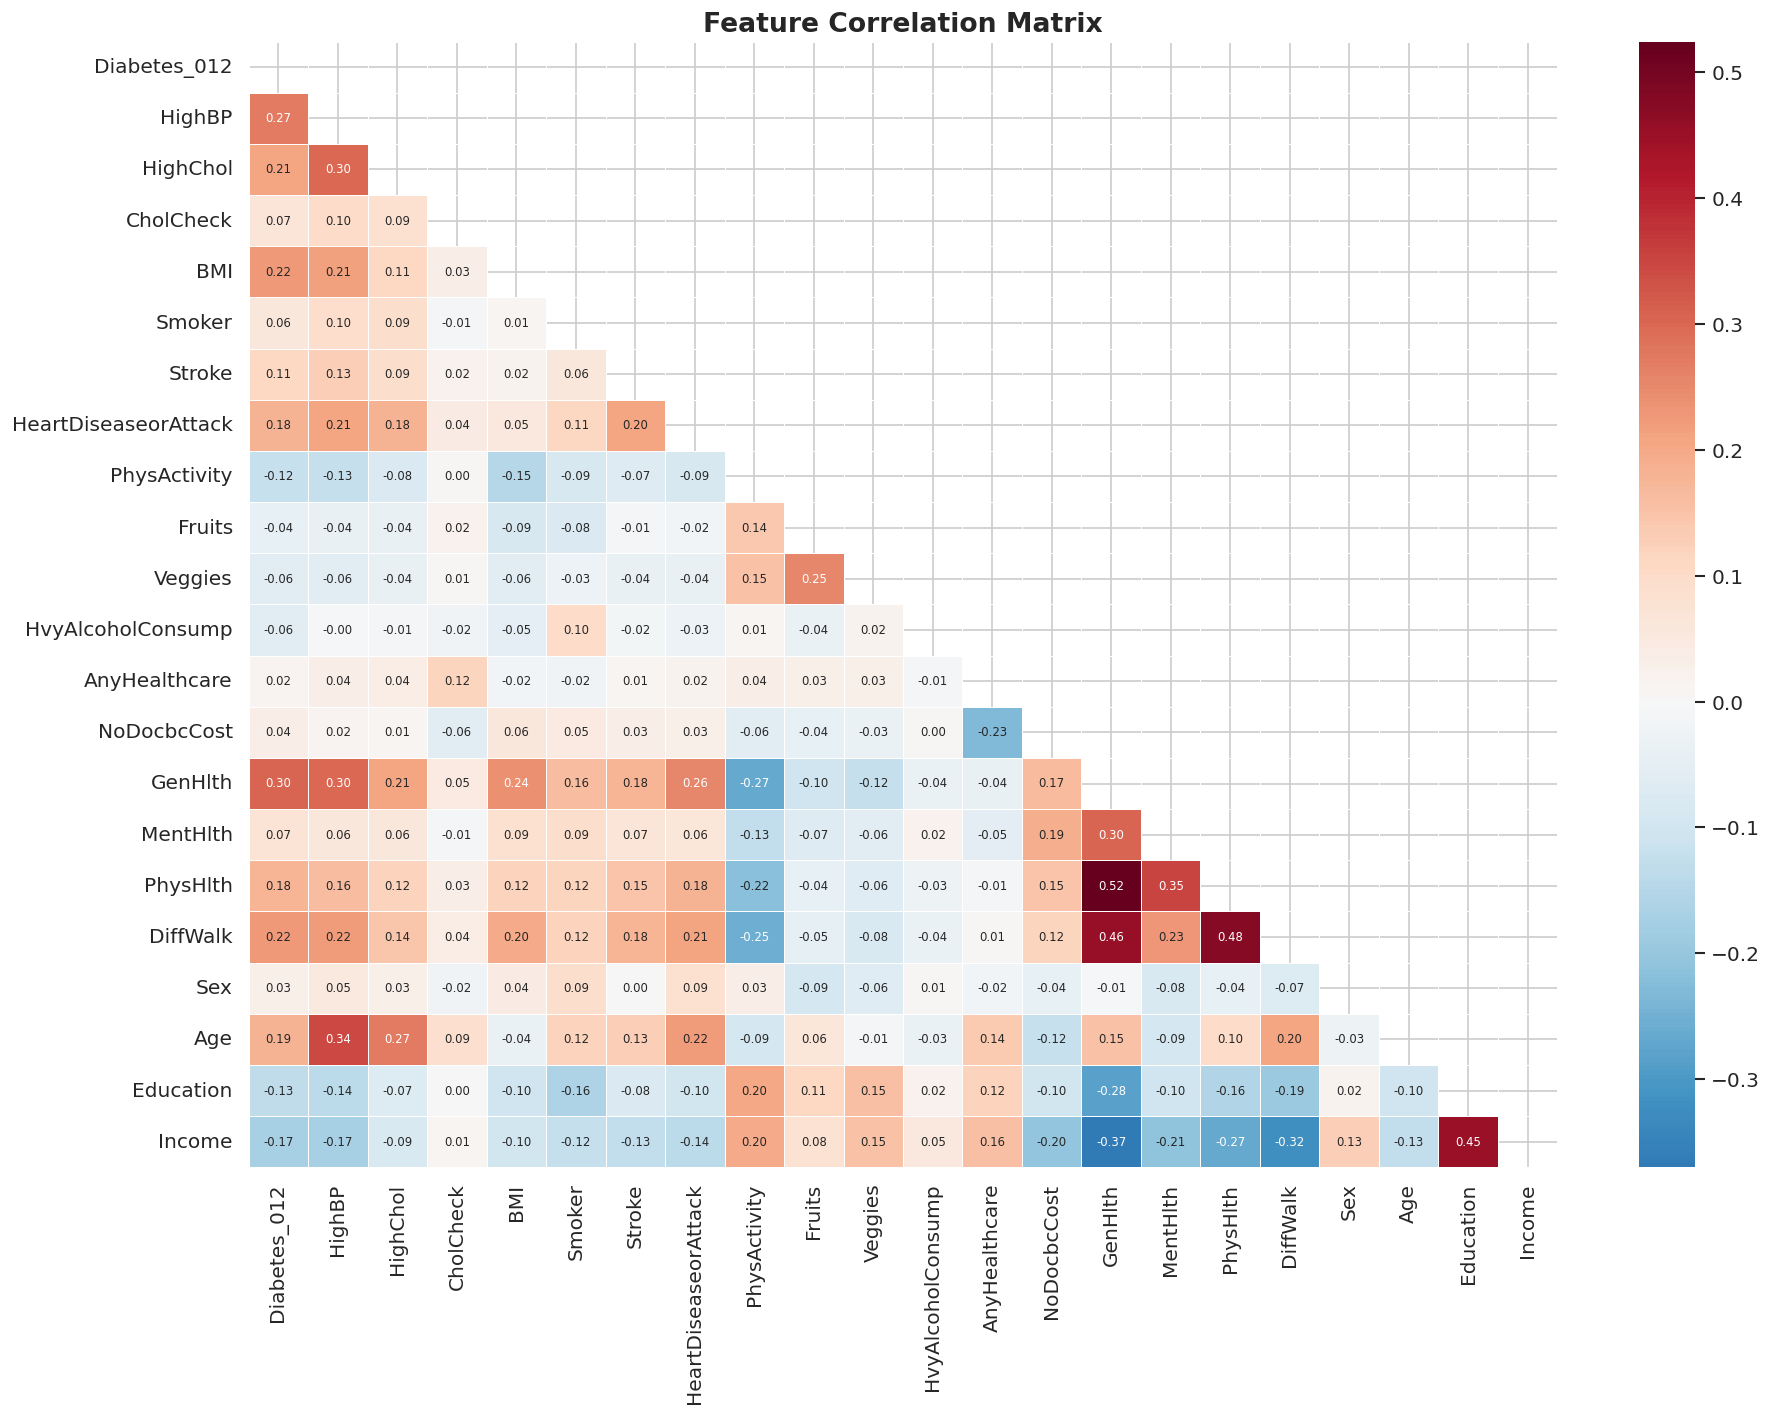

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 Features Correlated with Diabetes_012:

GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Income                 -0.171483
Education              -0.130517


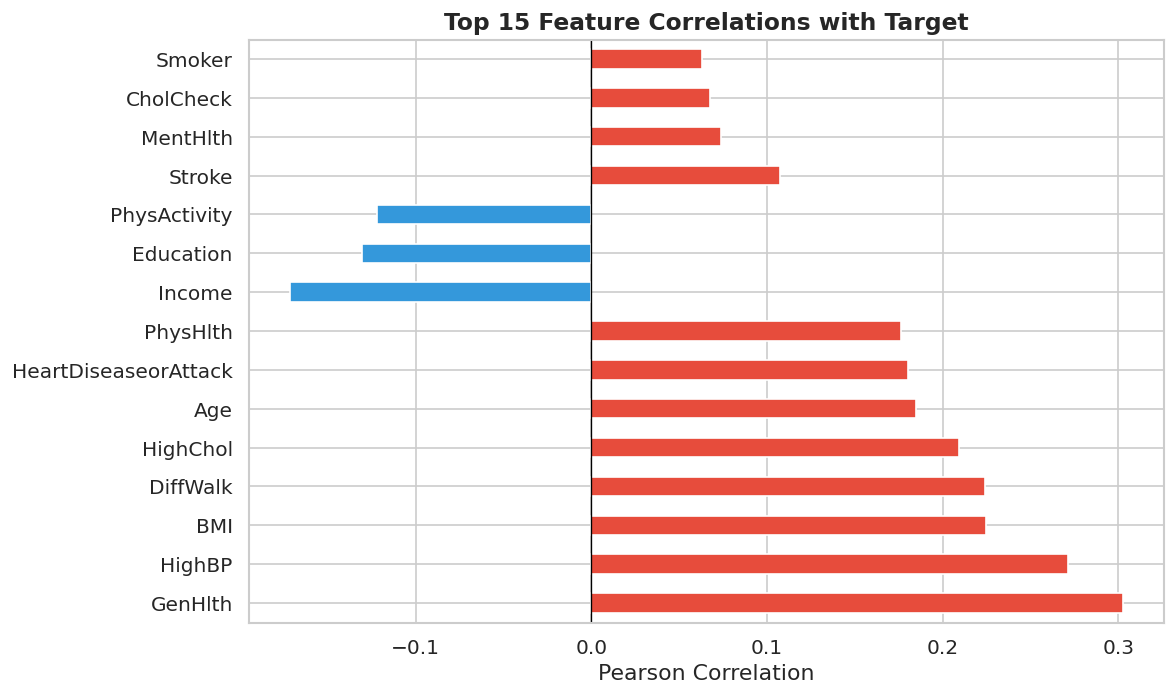

In [ ]:
# Top correlations with target
target_corr = corr['Diabetes_012'].drop('Diabetes_012').sort_values(key=abs, ascending=False)
print("Top 10 Features Correlated with Diabetes_012:\n")
print(target_corr.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
target_corr.head(15).plot(kind='barh', ax=ax, color=target_corr.head(15).apply(
    lambda x: '#e74c3c' if x > 0 else '#3498db'))
ax.set_title('Top 15 Feature Correlations with Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### 1.4 Κατανομές Features ανά Κλάση

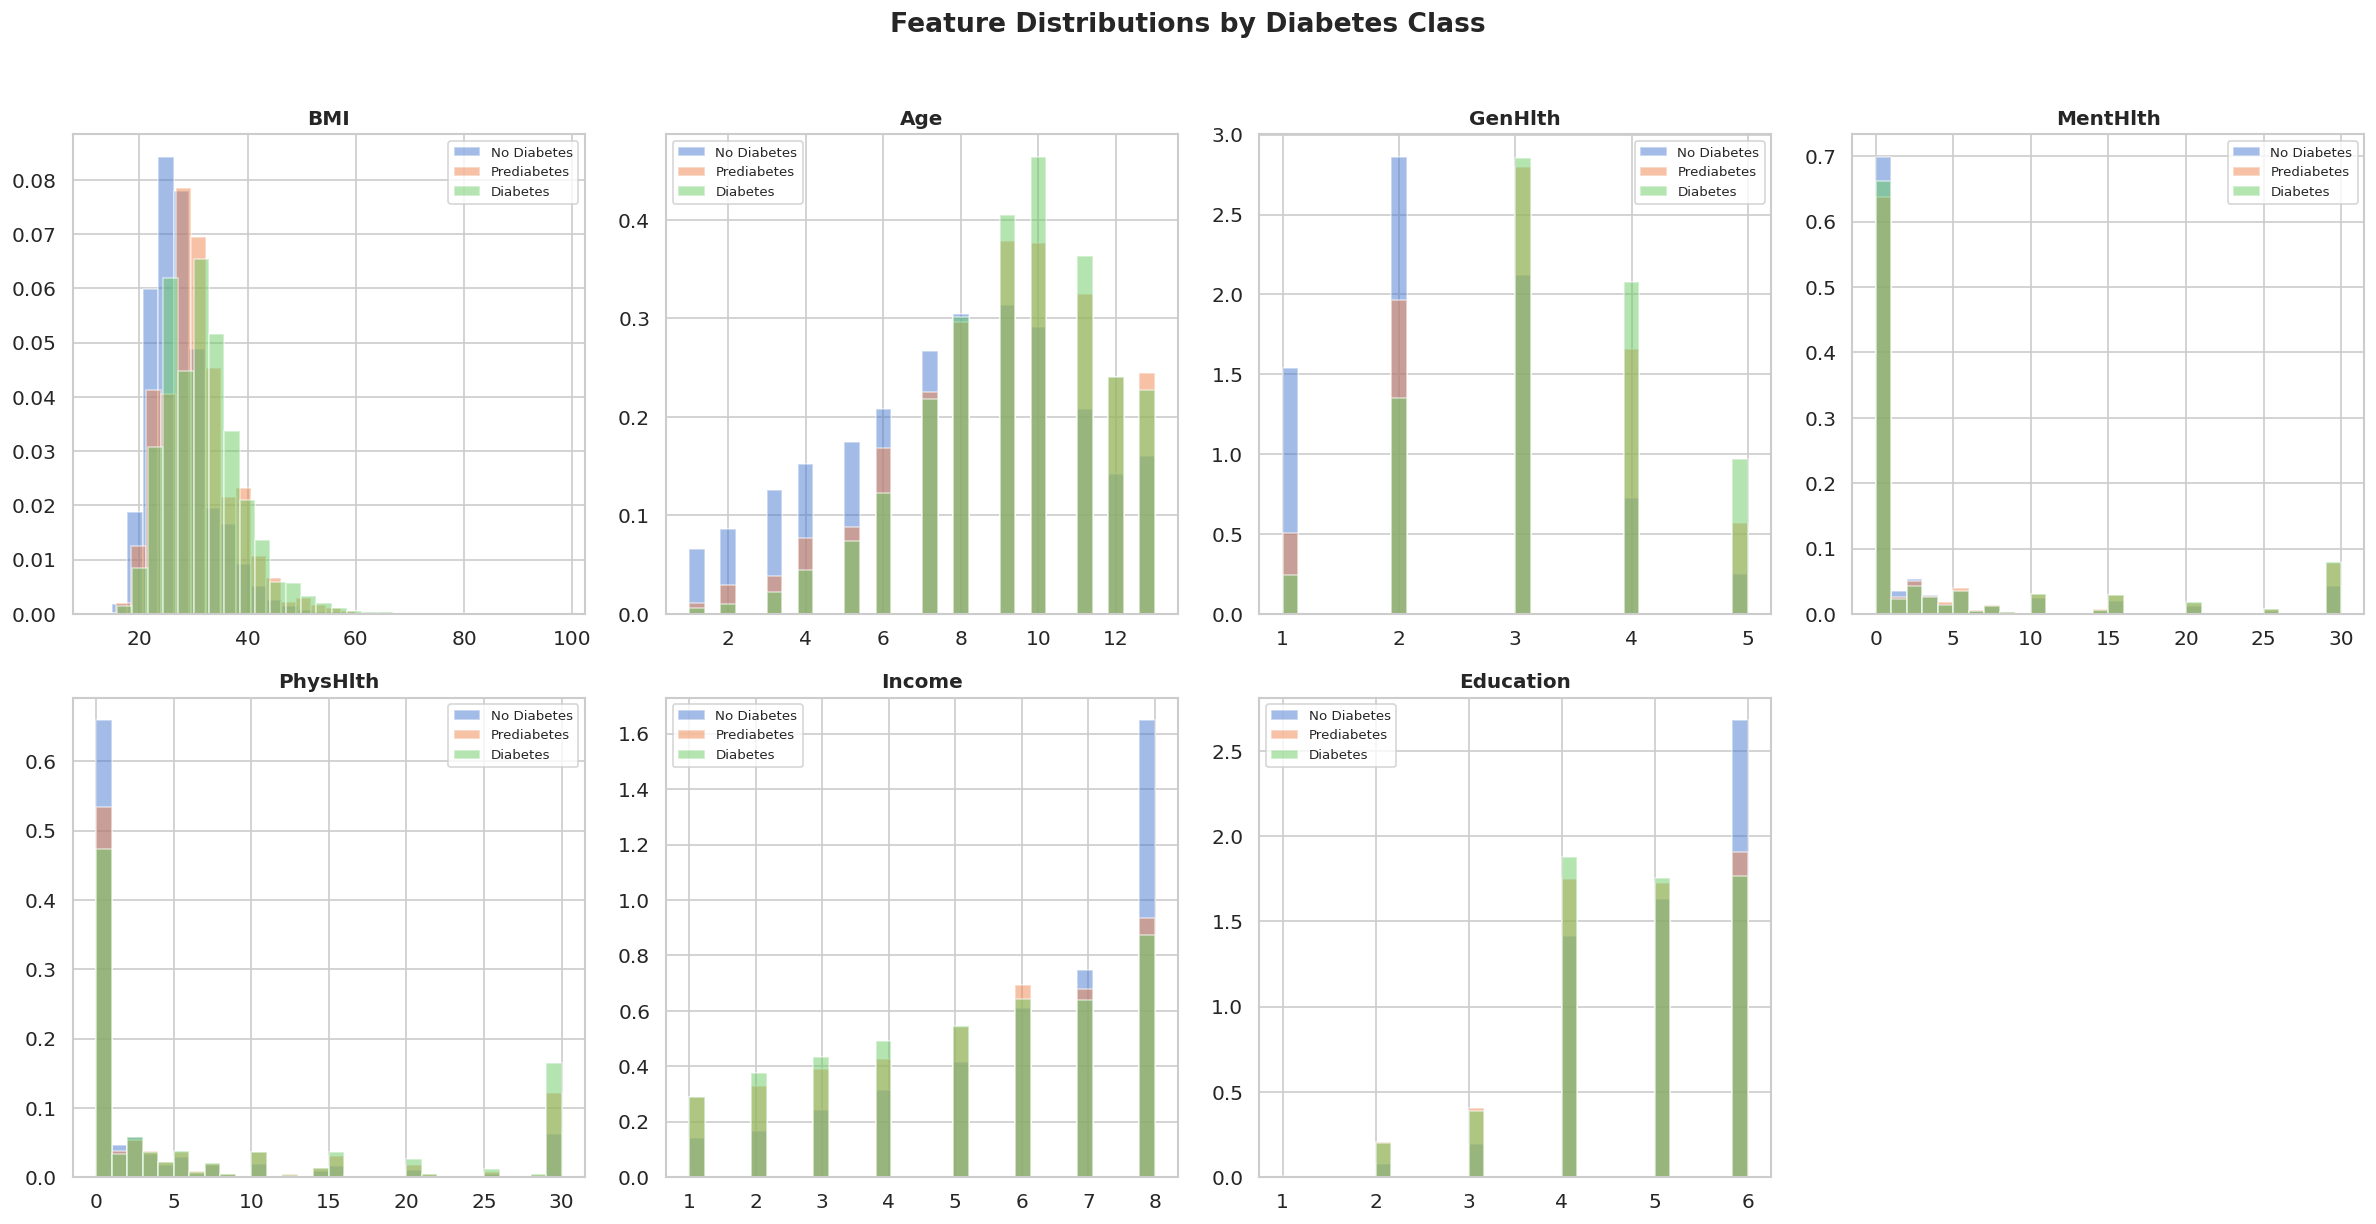

In [ ]:
continuous_features = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth', 'Income', 'Education']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    for cls in [0, 1, 2]:
        subset = df[df['Diabetes_012'] == cls][feat]
        axes[i].hist(subset, bins=30, alpha=0.5, label=class_map[cls], density=True)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)

# Remove unused subplot
if len(continuous_features) < len(axes):
    for j in range(len(continuous_features), len(axes)):
        fig.delaxes(axes[j])

fig.suptitle('Feature Distributions by Diabetes Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Box Plots για Βασικά Features

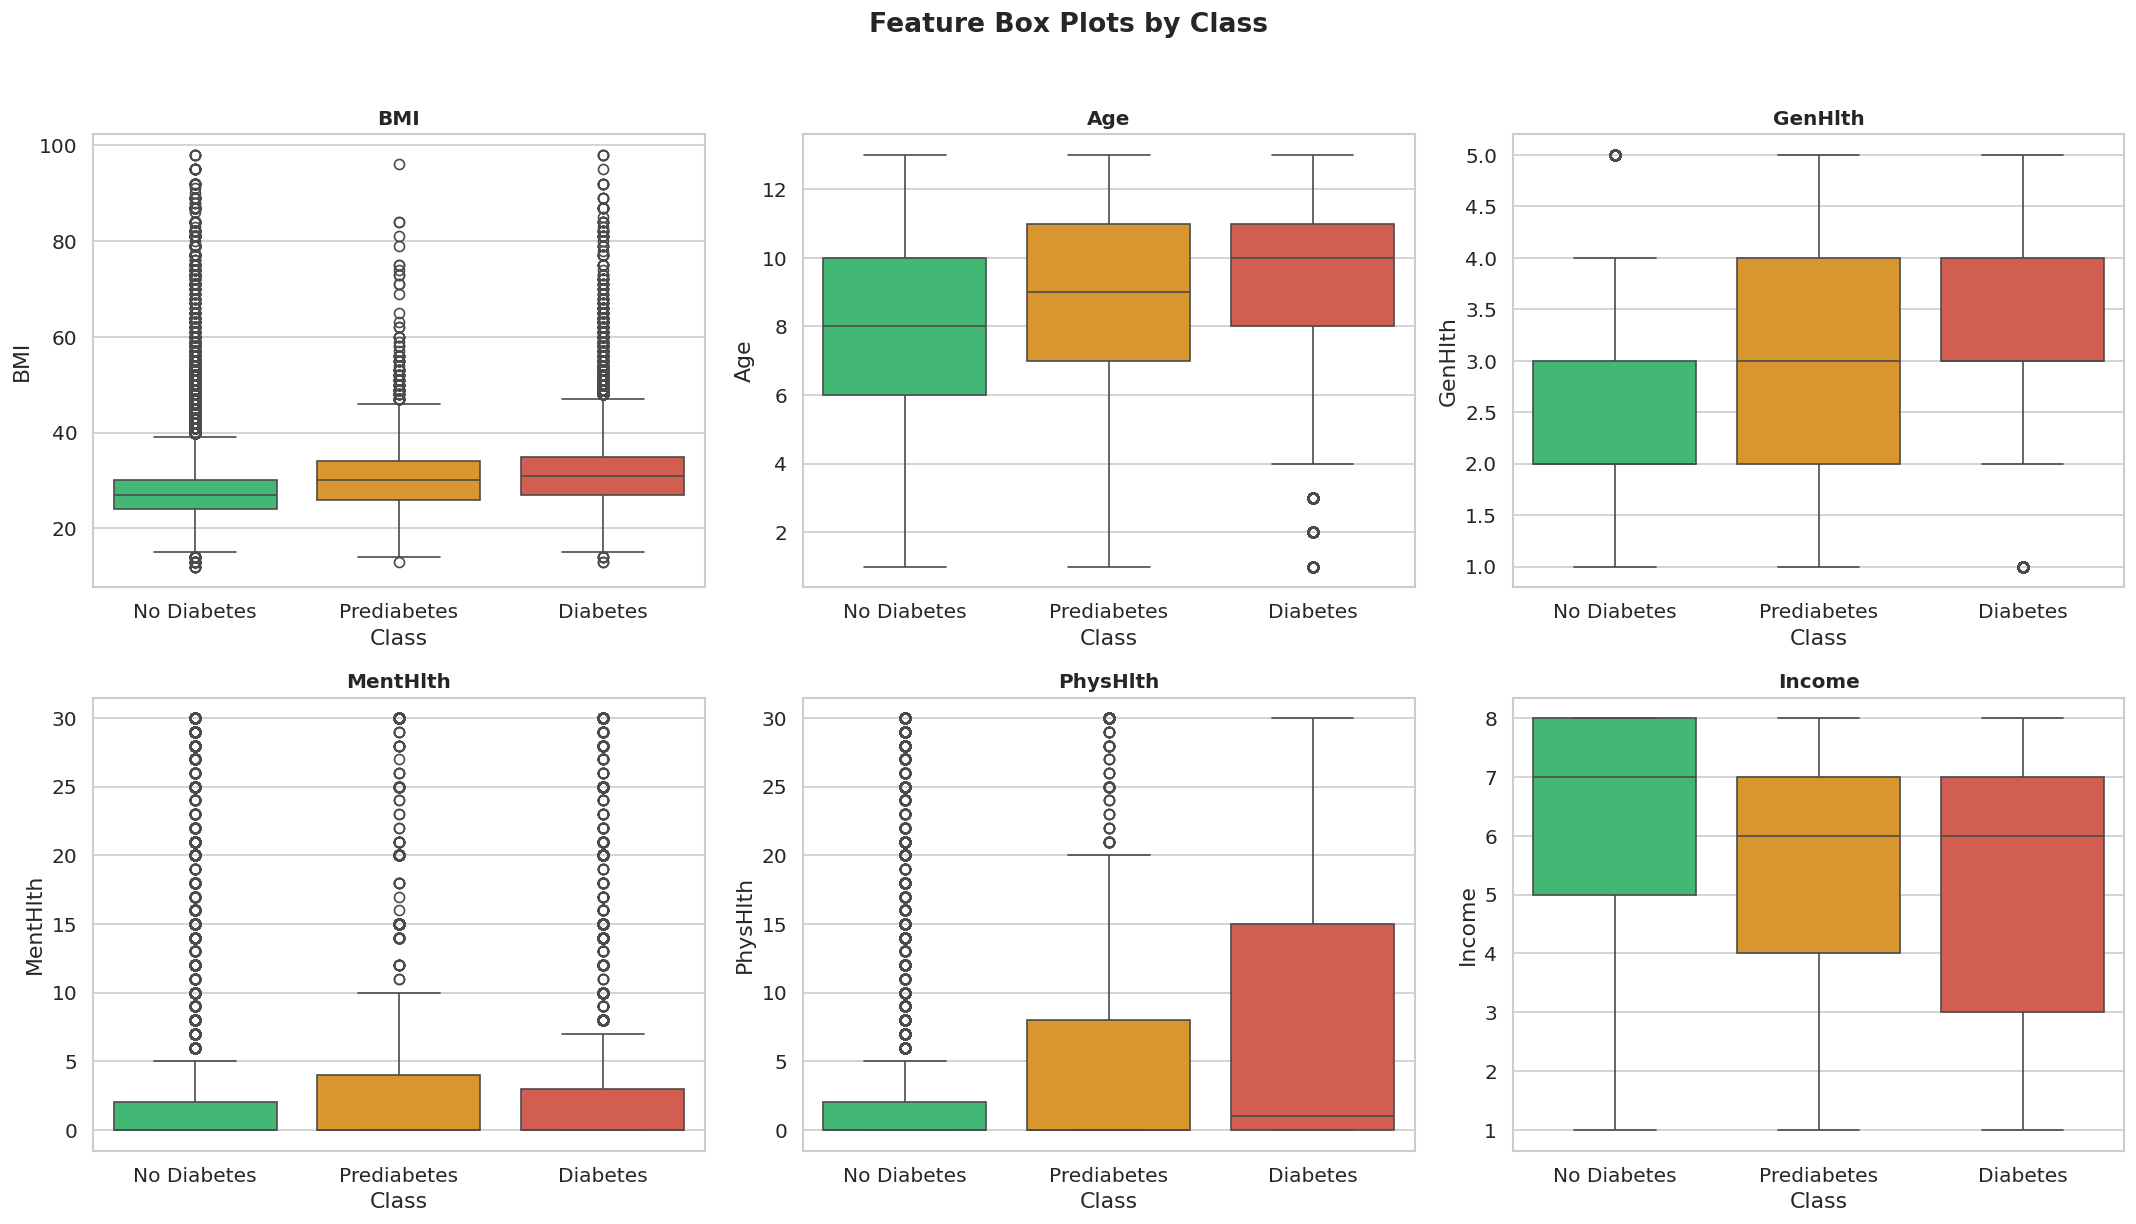

In [ ]:
key_features = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth', 'Income']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    df_plot = df[[feat, 'Diabetes_012']].copy()
    df_plot['Class'] = df_plot['Diabetes_012'].map(class_map)
    sns.boxplot(data=df_plot, x='Class', y=feat, ax=axes[i],
                palette=['#2ecc71', '#f39c12', '#e74c3c'],
                order=['No Diabetes', 'Prediabetes', 'Diabetes'])
    axes[i].set_title(feat, fontsize=12, fontweight='bold')

fig.suptitle('Feature Box Plots by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Από τα παραπάνω box plots μπορούμε να παρατηρήσουμε τα εξής:
* BMI (Δείκτης Μάζας Σώματος): Παρατηρείται σαφής αύξηση του BMI καθώς προχωράμε από την κλάση 'Χωρίς Διαβήτη' προς τον 'Προ-Διαβήτη' και τέλος στον 'Διαβήτη'. Οι ασθενείς με διαβήτη έχουν, κατά μέσο όρο, υψηλότερο BMI.
* Age (Ηλικία): Η μέση ηλικία φαίνεται να είναι αυξημένη στις κλάσεις 'Προ-Διαβήτη' και 'Διαβήτη' σε σύγκριση με την κλάση 'Χωρίς Διαβήτη', υποδεικνύοντας ότι ο διαβήτης είναι πιο διαδεδομένος σε μεγαλύτερες ηλικίες.
* GenHlth (Γενική Υγεία): Η γενική υγεία, όπως αναφέρεται από τους ασθενείς, φαίνεται να επιδεινώνεται (υψηλότερες τιμές) καθώς η κατάσταση του διαβήτη προχωράει από 'Χωρίς Διαβήτη' σε 'Προ-Διαβήτη' και 'Διαβήτη'.
* MentHlth (Ψυχική Υγεία): Οι κατανομές για τις ημέρες κακής ψυχικής υγείας φαίνονται σχετικά παρόμοιες μεταξύ των κλάσεων, με ελαφρώς υψηλότερες μεσαίες τιμές για τις ομάδες του διαβήτη και του προδιαβήτη, αλλά με σημαντική επικάλυψη.
* PhysHlth (Σωματική Υγεία): Όπως και στην γενική υγεία, οι ασθενείς με 'Προ-Διαβήτη' και 'Διαβήτη' αναφέρουν περισσότερες ημέρες κακής σωματικής υγείας, με την κλάση 'Διαβήτης' να έχει την υψηλότερη μέση τιμή.
* Income (Εισόδημα): Φαίνεται μια ελαφρά τάση μείωσης του εισοδήματος στις κλάσες 'Προ-Διαβήτη' και 'Διαβήτη' σε σύγκριση με την κλάση 'Χωρίς Διαβήτη'.

### 1.6 Ανάλυση Δυαδικών Features

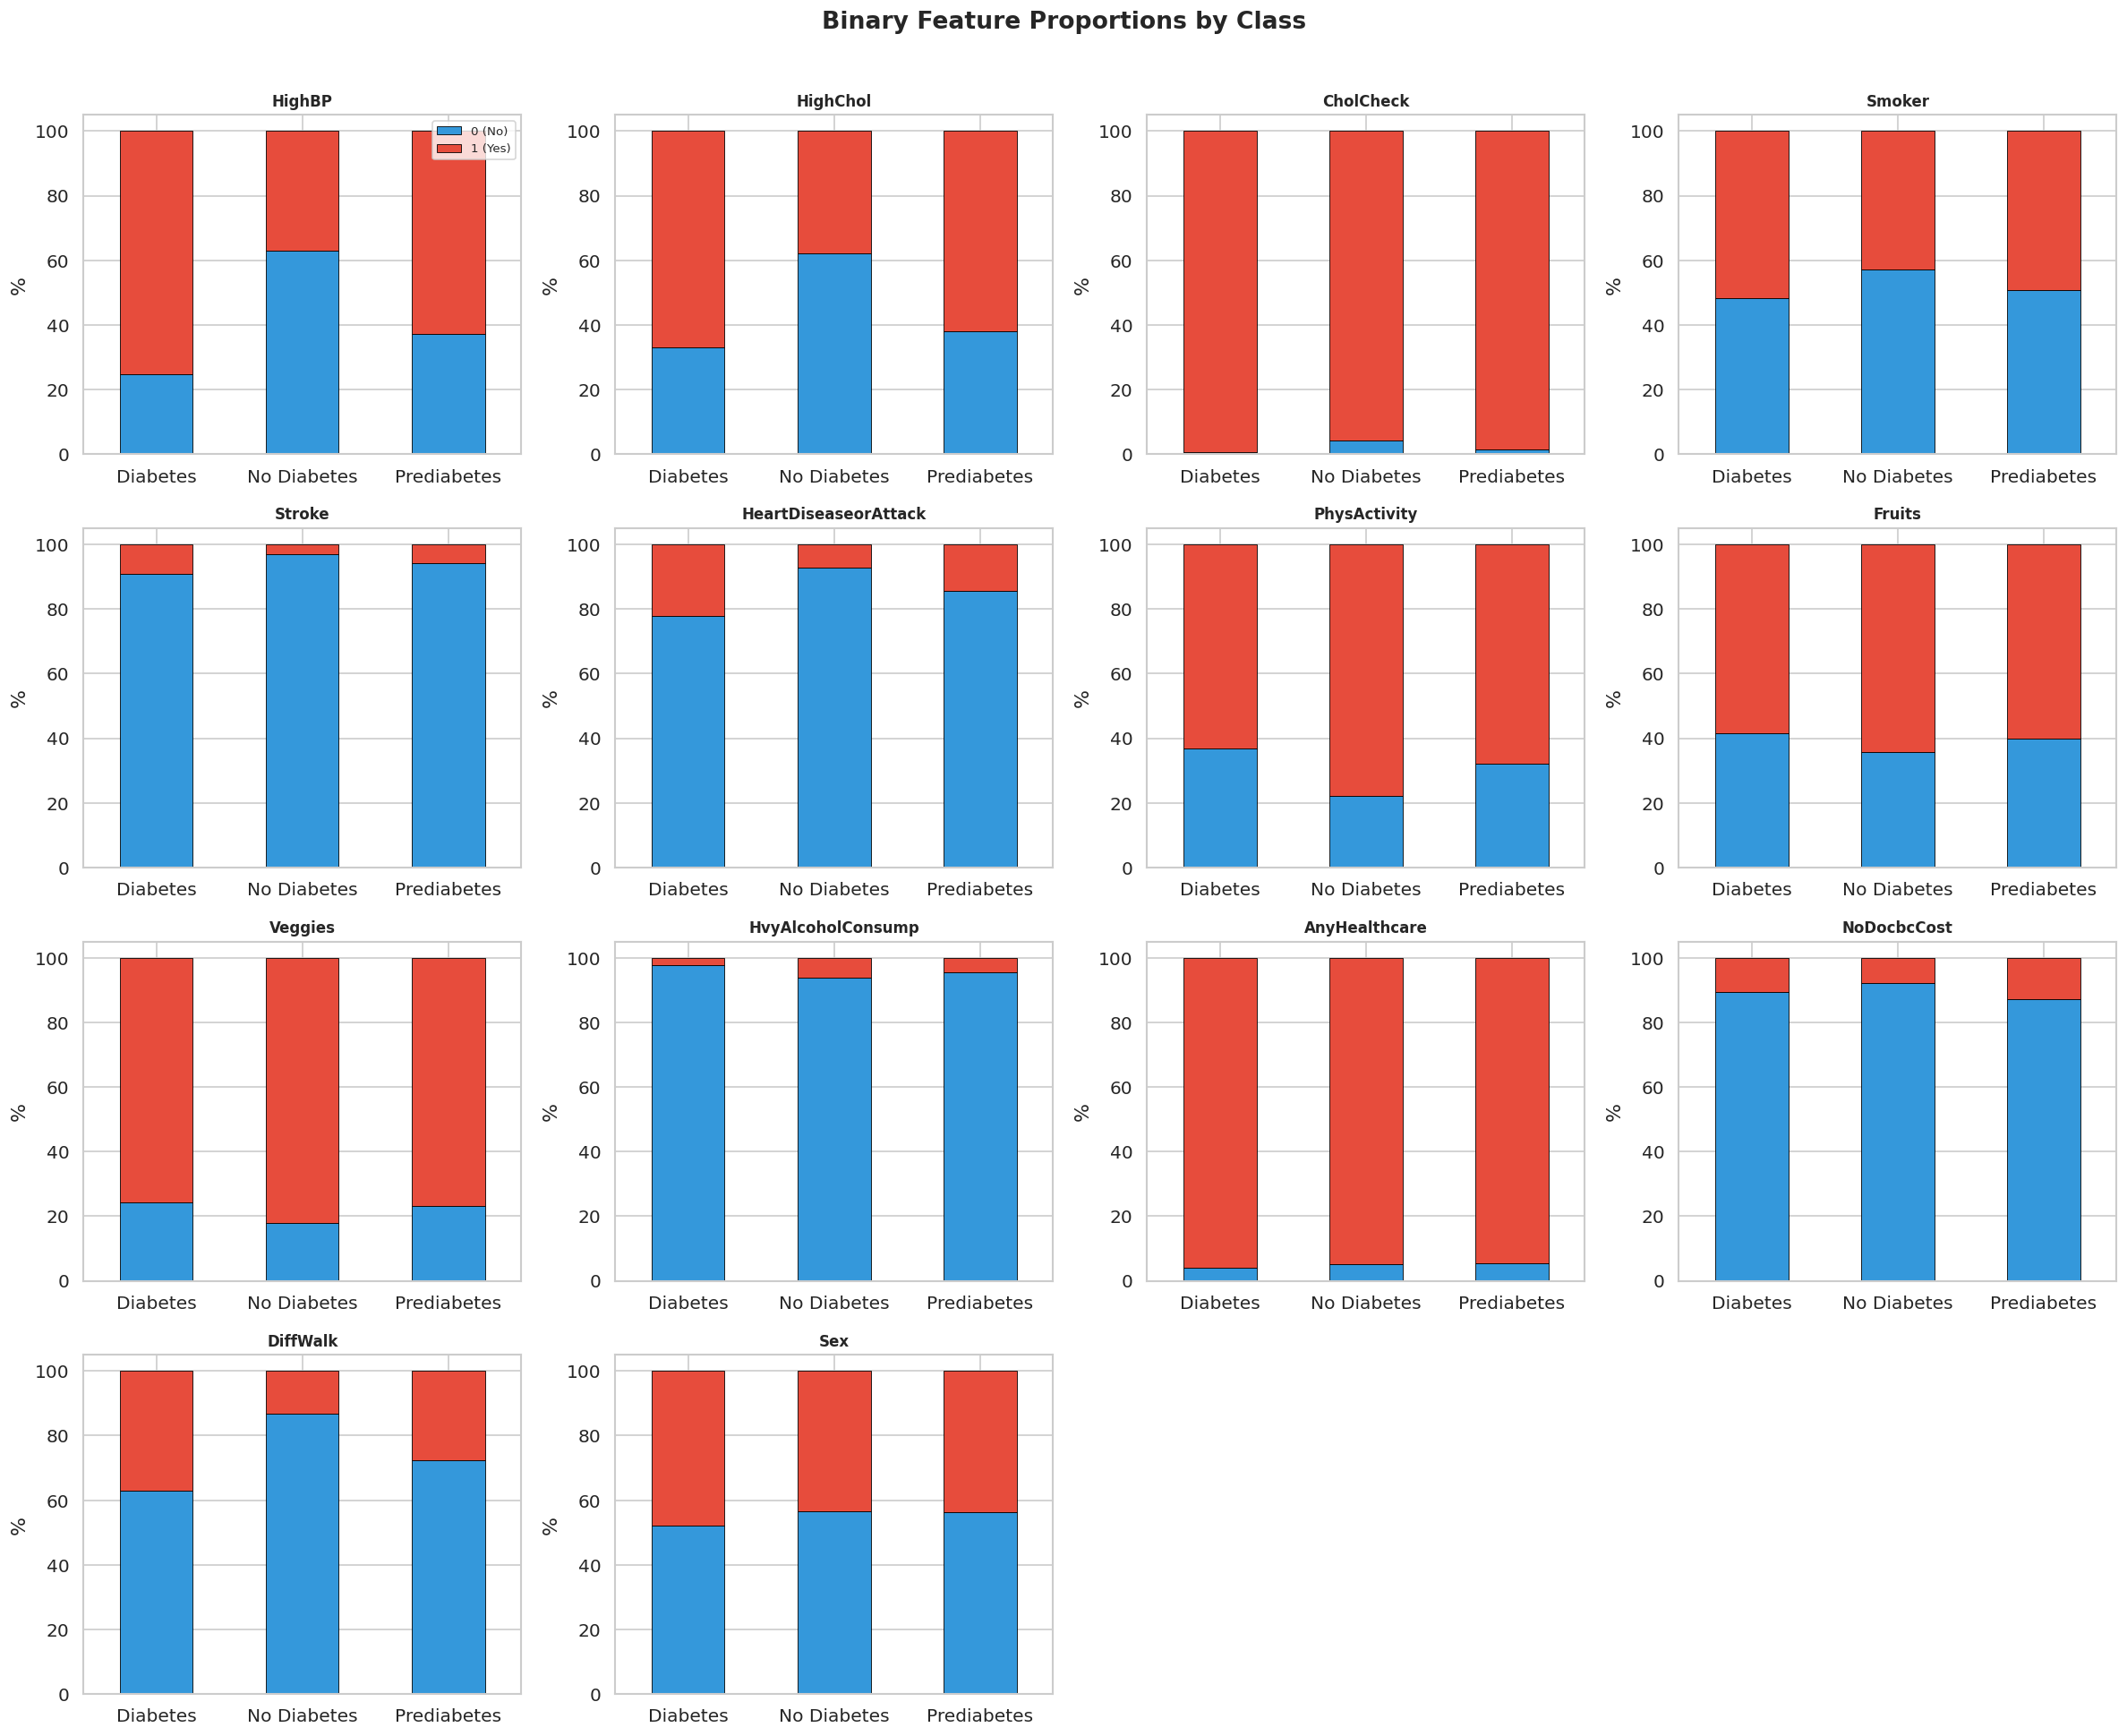

In [ ]:
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
                   'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
                   'Fruits', 'Veggies', 'HvyAlcoholConsump',
                   'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, feat in enumerate(binary_features):
    ct = pd.crosstab(df['Diabetes_012'].map(class_map), df[feat], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#3498db', '#e74c3c'],
            legend=False, edgecolor='black', linewidth=0.5)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(len(binary_features), len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(['0 (No)', '1 (Yes)'], loc='upper right', fontsize=8)
fig.suptitle('Binary Feature Proportions by Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.7 Οπτικοποίηση PCA

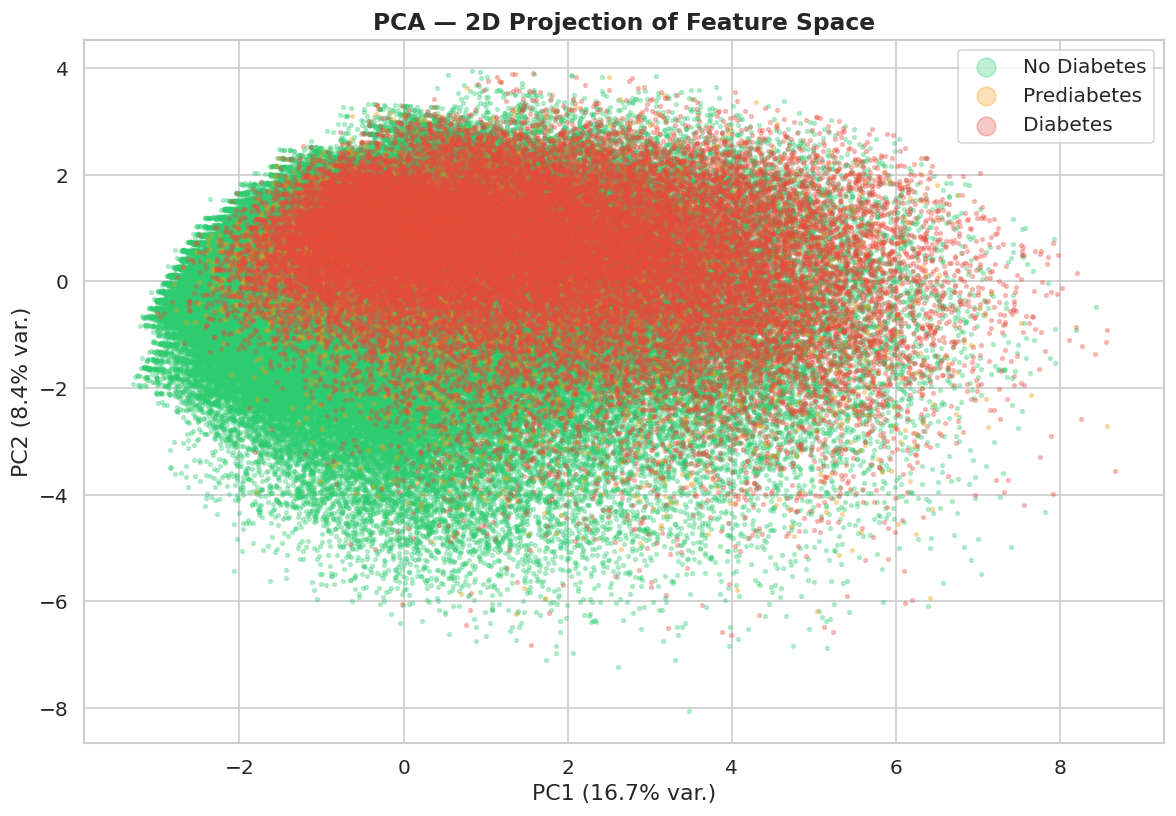

Explained variance: PC1=0.167, PC2=0.084, Total=0.251


In [ ]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
for cls in [0, 1, 2]:
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cls],
               label=class_map[cls], alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.set_title('PCA — 2D Projection of Feature Space', fontsize=14, fontweight='bold')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"Total={sum(pca.explained_variance_ratio_):.3f}")

Από το παραπάνω γράφημα παρατηρούμε ότι
* Υπάρχει ένα overlap μεταξύ των κλάσεων. Αυτό επισημαίνει ότι ακόμα και με την μέθοδο PCA οι κλάσεις δεν είναι διακριτά διαχωρίσιμες.

* Η κλάση 'Predicates' εμφανίζεται πολύ αραιή και με μεγάλο overlap μεταξύ την 'No Diabetes' κλάσης. Αυτό επιβεβαιώνει ότι η κλάση είναι μία από τις μειοψηφούσες και δύσκολα διαχωρίσιμη με βάση αυτά τα χαρακτηριστικά που προβάλλονται.

Παρατηρώντας επίσης τις μετρικές explained_variance_ratio βλέπουμε ότι είνια πολύ χαμηλές. PCA1 and PCA2 αναγνωρίζουν περίπου μόνο το $25%$ της πληροφορίας των δεδομένων, συμπαιραίνωντας έτσι ότι το υπόλοιπο $75%$, είναι "captured" από τα υπόλοιπα μη-απεικονιζόμενα principal-components. Επιβεβαιώνεται άρα πάλι ότι τα δεομένα είναι σύνθετα και όχι καλά διαχωρίσιμα.

### 1.8 Περιγραφικά Στατιστικά ανά Κλάση

In [ ]:
for cls in [0, 1, 2]:
    print(f"\n{'='*60}")
    print(f"  CLASS {cls} — {class_map[cls]}  (n = {(y == cls).sum():,})")
    print(f"{'='*60}")
    print(df[df['Diabetes_012'] == cls].describe().T[['mean', 'std', 'min', 'max']].round(2).to_string())


  CLASS 0 — No Diabetes  (n = 213,703)
                       mean   std   min   max
Diabetes_012           0.00  0.00   0.0   0.0
HighBP                 0.37  0.48   0.0   1.0
HighChol               0.38  0.49   0.0   1.0
CholCheck              0.96  0.20   0.0   1.0
BMI                   27.74  6.26  12.0  98.0
Smoker                 0.43  0.50   0.0   1.0
Stroke                 0.03  0.18   0.0   1.0
HeartDiseaseorAttack   0.07  0.26   0.0   1.0
PhysActivity           0.78  0.41   0.0   1.0
Fruits                 0.64  0.48   0.0   1.0
Veggies                0.82  0.38   0.0   1.0
HvyAlcoholConsump      0.06  0.24   0.0   1.0
AnyHealthcare          0.95  0.22   0.0   1.0
NoDocbcCost            0.08  0.27   0.0   1.0
GenHlth                2.37  1.02   1.0   5.0
MentHlth               2.94  7.06   0.0  30.0
PhysHlth               3.58  8.00   0.0  30.0
DiffWalk               0.13  0.34   0.0   1.0
Sex                    0.43  0.50   0.0   1.0
Age                    7.79  3.10   1.0 

---
# ΜΕΡΟΣ 2 — Εκπαίδευση Baseline Μοντέλων στα Αρχικά Δεδομένα
---

### 2.1 Διαχωρισμός Train Set / Test Set & Scaling

In [ ]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts().sort_index().to_string())

Training set: 202,944 samples
Test set:     50,736 samples

Training class distribution:
Diabetes_012
0.0    170962
1.0      3705
2.0     28277


### 2.2 Βοηθητικές Συναρτήσεις Αξιολόγησης

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    """Train, predict, and return a full evaluation dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)

    report = classification_report(y_te, y_pred, output_dict=True, zero_division=0)

    results = {
        'Model': model_name,
        'F1_macro': f1_score(y_te, y_pred, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_te, y_pred, average='weighted', zero_division=0),
        'Precision_macro': precision_score(y_te, y_pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_te, y_pred, average='macro', zero_division=0),
    }

    # Per-class metrics
    for cls in sorted(y_te.unique()):
        cls_str = str(cls)
        results[f'F1_class{cls}'] = report[cls_str]['f1-score']
        results[f'Precision_class{cls}'] = report[cls_str]['precision']
        results[f'Recall_class{cls}'] = report[cls_str]['recall']

    # AUC-ROC (One-vs-Rest)
    try:
        results['AUC_ROC_ovr'] = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro')
    except:
        results['AUC_ROC_ovr'] = np.nan

    return results, y_pred, y_proba, report


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """Plot a styled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[class_map[i] for i in sorted(y_true.unique())],
                yticklabels=[class_map[i] for i in sorted(y_true.unique())],
                ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_roc_curves(y_true, y_proba, title='ROC Curves'):
    """Plot OvR ROC curves for each class."""
    from sklearn.preprocessing import label_binarize
    classes = sorted(y_true.unique())
    y_bin = label_binarize(y_true, classes=classes)

    fig, ax = plt.subplots(figsize=(8, 6))
    colors_roc = ['#2ecc71', '#f39c12', '#e74c3c']

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f'{class_map[cls]} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

### 2.3 Εκπαίδευση μοντέλων και εύρεση βέλτιστων υπερπαραμέτρων

Θα εκπαιδεύσουμε 2 baseline μοντέλα:
* Random Forest Classifier
* XGBoost Model

Αρχικά πραγματοποιούμε Hyperparameter Tuning για κάθε μοντέλο προς εύρεση των βέλτιστων παραμέτρων με GridSearchCV:

#### 1. Random Forest - Baseline

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

rf_param_grid = {
    'n_estimators': [150, 300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

rf_model = RandomForestClassifier(random_state=SEED, n_jobs=-1)

start_time = time.time()

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1_macro',   # better for multiclass than plain 'f1'
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_scaled, y_train)

rf_time = time.time() - start_time

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV F1 Score: {rf_grid.best_score_:.4f}")
print(f"Training Time: {rf_time:.2f} seconds")

base_rf = rf_grid.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


KeyboardInterrupt: 

=== Random Forest — Baseline ===
              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.92     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.58      0.15      0.23      7069

    accuracy                           0.85     50736
   macro avg       0.48      0.38      0.38     50736
weighted avg       0.80      0.85      0.81     50736



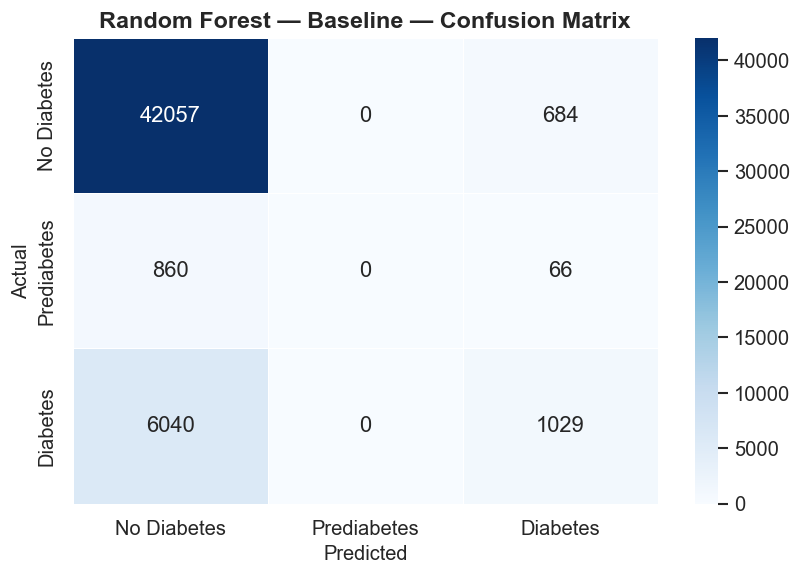

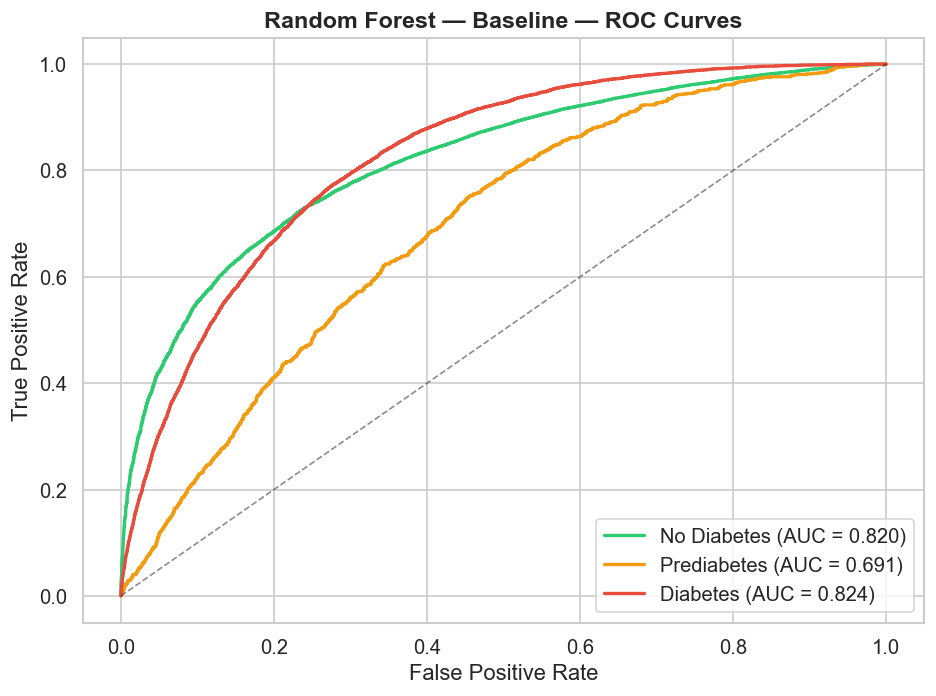

In [ ]:
rf_results, rf_pred, rf_proba, rf_report = evaluate_model(
    base_rf, X_train_scaled, y_train, X_test_scaled, y_test, 'RF_Baseline')

print("=== Random Forest ===")
print(classification_report(
    y_test,
    rf_pred,
    target_names=[class_map[i] for i in [0,1,2]],
    zero_division=0
))

plot_confusion_matrix(y_test, rf_pred, 'Random Forest - Confusion Matrix')
plot_roc_curves(y_test, rf_proba, 'Random Forest - ROC Curves')

Το μοντέλο Random Forest εκπαιδεύτηκε στο αρχικό, μη ισορροπημένο dataset χωρίς καμία τεχνική αύξησης δεδομένων. Σύμφωνα με τις μετρικές αξιλόγησης παίρνουμε τις εξής παρατηρήσεις:


* Ακρίβεια (Accuracy: 0.85): Αυτό σημαίνει ότι το 85% των προβλέψεων του μοντέλου ήταν συνολικά σωστές. Ωστόσο, αυτή η τιμή μπορεί να είναι παραπλανητική σε μη ισορροπημένα σύνολα δεδομένων, καθώς το μοντέλο μπορεί να επιτύχει υψηλή ακρίβεια προβλέποντας απλώς την πλειοψηφούσα κλάση (No Diabetes).

* F1-Score (Macro Avg: 0.38):

  * Κλάση 0 (No Diabetes): F1-score = 0.92: Το μοντέλο αποδίδει εξαιρετικά στον εντοπισμό ατόμων χωρίς διαβήτη. Αυτό είναι αναμενόμενο, καθώς αυτή είναι η συντριπτική πλειοψηφία των δεδομένων.
  * Κλάση 1 (Prediabetes): F1-score = 0.00: Αυτή είναι μια κρίσιμη παρατήρηση. Το F1-score 0.00 δείχνει ότι το μοντέλο αποτυγχάνει πλήρως να εντοπίσει οποιεσδήποτε περιπτώσεις 'Προ-Διαβήτη'. Τόσο η ακρίβεια (precision) όσο και η ανάκλησή (recall) του για αυτή την κλάση είναι 0.
  * Κλάση 2 (Diabetes): F1-score = 0.23: Το μοντέλο έχει πολύ χαμηλή απόδοση στον εντοπισμό ατόμων με 'Διαβήτη', αν και ελαφρώς καλύτερη από ό,τι για τον 'Προ-Διαβήτη'.
  * Το macro average F1-score (0.38) είναι χαμηλό, αντανακλώντας τη φτωχή απόδοση στις μειοψηφούσες κλάσεις (Προ-Διαβήτης και Διαβήτης).
* Ακρίβεια (Precision) (Macro Avg: 0.48):

  * Κλάση 0 (No Diabetes): Precision = 0.86: Όταν το μοντέλο προβλέπει 'No Diabetes', είναι σωστό στο 86% των περιπτώσεων.
  * Κλάση 1 (Prediabetes): Precision = 0.00: Το μοντέλο δεν προβλέπει ποτέ σωστά τον 'Προ-Διαβήτη'.
  * Κλάση 2 (Diabetes): Precision = 0.58: Όταν το μοντέλο προβλέπει 'Διαβήτη', είναι σωστό στο 58% των περιπτώσεων. Αυτό είναι λογικό, αλλά σπάνια κάνει αυτή την πρόβλεψη, όπως φαίνεται από τη χαμηλή ανάκληση.
* Ανάκληση (Recall) (Macro Avg: 0.38):

  * Κλάση 0 (No Diabetes): Recall = 0.98: Το μοντέλο εντοπίζει σωστά το 98% όλων των ατόμων που στην πραγματικότητα δεν έχουν διαβήτη.
  * Κλάση 1 (Prediabetes): Recall = 0.00: Το μοντέλο αποτυγχάνει να εντοπίσει οποιαδήποτε από τις πραγματικές περιπτώσεις 'Προ-Διαβήτη'.
  * Κλάση 2 (Diabetes): Recall = 0.15: Το μοντέλο εντοπίζει μόνο το 15% όλων των ατόμων που στην πραγματικότητα έχουν 'Διαβήτη'.
* AUC-ROC (OvR, Macro: 0.78): Ένα AUC-ROC 0.78 υποδηλώνει μια αξιοπρεπή ικανότητα του μοντέλου να διακρίνει μεταξύ των κλάσεων συνολικά σε διαφορετικά όρια ταξινόμησης. Ωστόσο, αυτή η μακρο-μετρική μπορεί να επηρεαστεί από την καλή απόδοση στην πλειοψηφούσα κλάση, κρύβοντας προβλήματα με τις μειοψηφούσες κλάσεις.

Το Random Forest Baseline:
Αυτό το μοντέλο πάσχει ξεκάθαρα από την ανισορροπία των κλάσεων. Είναι έντονα προκατειλημμένο προς την πλειοψηφούσα κλάση (No Diabetes), επιτυγχάνοντας υψηλή ακρίβεια και ανάκληση για αυτήν, αλλά αποτυγχάνοντας πλήρως να προβλέψει την κλάση Prediabetes και αποδίδοντας πολύ άσχημα στην κλάση Diabetes. Αυτό σημαίνει ότι δεν θα ήταν ένα αξιόπιστο μοντέλο για τον εντοπισμό ατόμων που διατρέχουν κίνδυνο, κάτι που είναι βασικός στόχος στην πρόβλεψη του διαβήτη.

Αυτό το αποτέλεσμα υπογραμμίζει έντονα την αναγκαιότητα χρήσης τεχνικών αύξησης δεδομένων (όπως SMOTE, CTGAN ή VAE) για την αντιμετώπιση της ανισορροπίας και τη βελτίωση της ικανότητας του μοντέλου να μαθαίνει και να προβλέπει τις μειοψηφούσες κλάσεις.

#### XGBoost — Baseline



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import time

# Optimized for medical dataset
xgb_param_grid = {
    'n_estimators': [150, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0, 0.1]
}

xgb_model = XGBClassifier(
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

start_time = time.time()

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1_macro',   # IMPORTANT: multiclass-safe
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_scaled, y_train)

xgb_time = time.time() - start_time

print(f"\nBest Parameters: {xgb_grid.best_params_}")
print(f"Best CV F1 Score: {xgb_grid.best_score_:.4f}")
print(f"Training Time: {xgb_time:.2f} seconds")

base_xgb = xgb_grid.best_estimator_

=== XGBoost — Baseline ===
              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.92     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.56      0.19      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.40     50736
weighted avg       0.81      0.85      0.81     50736



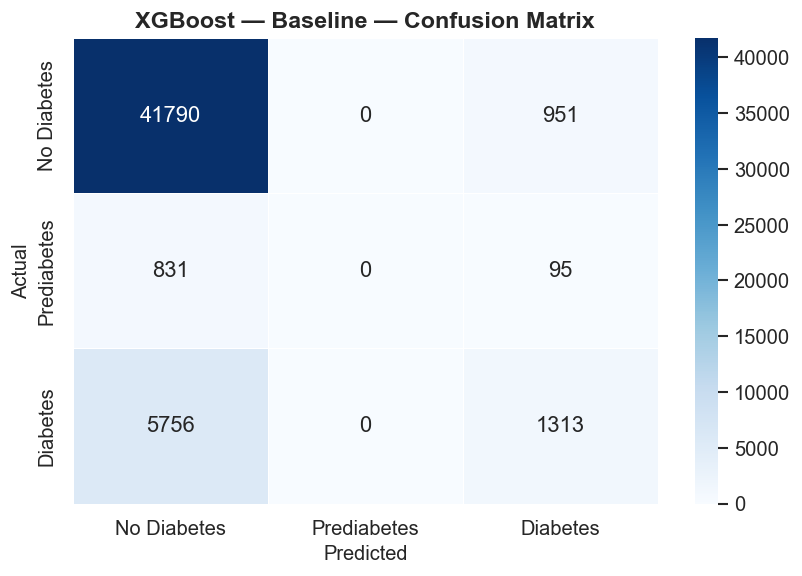

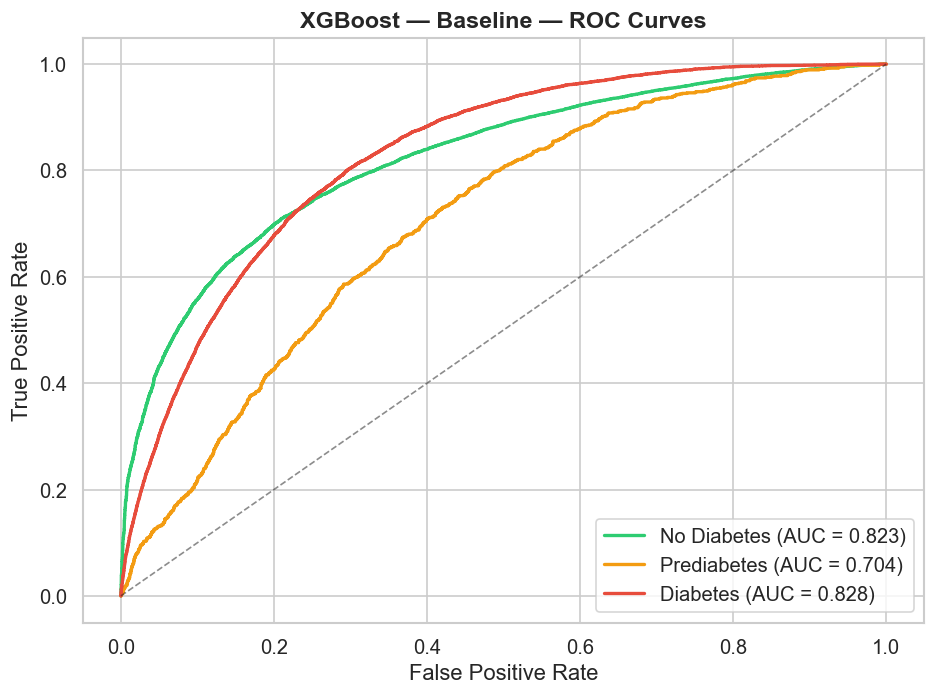

In [ ]:
xgb_results, xgb_pred, xgb_proba, xgb_report = evaluate_model(
    base_xgb, X_train_scaled, y_train, X_test_scaled, y_test, 'XGB_Baseline')

print("=== XGBoost — Tuned ===")
print(classification_report(
    y_test,
    xgb_pred,
    target_names=[class_map[i] for i in [0,1,2]],
    zero_division=0
))

plot_confusion_matrix(y_test, xgb_pred, 'XGBoost - Confusion Matrix')
plot_roc_curves(y_test, xgb_proba, 'XGBoost - ROC Curves')

Το μοντέλο XGBoost, όπως και το Random Forest Baseline, εκπαιδεύτηκε στο αρχικό, μη ισορροπημένο dataset. Οι αξιολογήσεις δείχνουν:

* Ακρίβεια (Accuracy: 0.85): Όπως και με το Random Forest, το 85% των προβλέψεων του μοντέλου ήταν συνολικά σωστές. Ωστόσο, αυτή η υψηλή ακρίβεια είναι και πάλι παραπλανητική λόγω της ανισορροπίας των κλάσεων, καθώς το μοντέλο υπερ-προβλέπει την πλειοψηφούσα κλάση ('No Diabetes').

* F1-Score (Macro Avg: 0.40):

 * * Κλάση 0 (No Diabetes): F1-score = 0.92: Το μοντέλο έχει εξαιρετική απόδοση στην αναγνώριση ατόμων χωρίς διαβήτη, κάτι που αναμένεται λόγω της συντριπτικής πλειοψηφίας αυτής της κλάσης.
   * Κλάση 1 (Prediabetes): F1-score = 0.00: Όπως και με το Random Forest, το μοντέλο αποτυγχάνει πλήρως να εντοπίσει οποιαδήποτε περίπτωση 'Προ-Διαβήτη'. Τόσο η ακρίβεια (precision) όσο και η ανάκλησή (recall) του για αυτή την κλάση είναι 0.
   *  Κλάση 2 (Diabetes): F1-score = 0.28: Η απόδοση στην αναγνώριση της κλάσης 'Διαβήτης' είναι πολύ χαμηλή, αν και ελαφρώς καλύτερη από του Random Forest (0.28 έναντι 0.23).
   *  Το macro average F1-score (0.40) είναι χαμηλό, υποδεικνύοντας τη φτωχή συνολική απόδοση του μοντέλου στις μειοψηφούσες κλάσεις.
* Ακρίβεια (Precision) (Macro Avg: 0.47):

  * Κλάση 0 (No Diabetes): Precision = 0.86: Όταν το μοντέλο προβλέπει 'No Diabetes', είναι σωστό στο 86% των περιπτώσεων.
  * Κλάση 1 (Prediabetes): Precision = 0.00: Το μοντέλο δεν κάνει καμία σωστή πρόβλεψη για 'Προ-Διαβήτη'.
  * Κλάση 2 (Diabetes): Precision = 0.56: Όταν προβλέπει 'Διαβήτη', είναι σωστό στο 56% των περιπτώσεων. Αυτή η τιμή είναι λογική, αλλά το μοντέλο σπάνια κάνει αυτή την πρόβλεψη, όπως φαίνεται από τη χαμηλή ανάκληση.
* Ανάκληση (Recall) (Macro Avg: 0.39):

  * Κλάση 0 (No Diabetes): Recall = 0.98: Το μοντέλο αναγνωρίζει σωστά το 98% όλων των ατόμων που στην πραγματικότητα δεν έχουν διαβήτη.
  * Κλάση 1 (Prediabetes): Recall = 0.00: Το μοντέλο αποτυγχάνει να αναγνωρίσει οποιαδήποτε από τις πραγματικές περιπτώσεις 'Προ-Διαβήτη'.
  * Κλάση 2 (Diabetes): Recall = 0.19: Το μοντέλο αναγνωρίζει μόνο το 19% όλων των ατόμων που στην πραγματικότητα έχουν 'Διαβήτη'. Αυτή η τιμή είναι ελαφρώς καλύτερη από το Random Forest (0.19 έναντι 0.15).
* AUC-ROC (OvR, Macro: 0.79): Ένα AUC-ROC 0.79 υποδηλώνει μια αξιοπρεπή ικανότητα διάκρισης μεταξύ των κλάσεων συνολικά. Ωστόσο, όπως και πριν, αυτή η μακρο-μετρική επηρεάζεται έντονα από την καλή απόδοση στην πλειοψηφούσα κλάση και κρύβει την αδυναμία στις μειοψηφούσες κλάσεις.

### 2.5 Σύνοψη Αποτελεσμάτων Baseline

In [ ]:
baseline_df = pd.DataFrame([rf_results, xgb_results]).set_index('Model')
print("\n" + "="*80)
print("  BASELINE RESULTS SUMMARY")
print("="*80)
baseline_df.T.round(4)


  BASELINE RESULTS SUMMARY


Model,RF_Baseline,XGB_Baseline
F1_macro,0.3833,0.3986
F1_weighted,0.8052,0.8115
Precision_macro,0.4792,0.4735
Recall_macro,0.3765,0.3878
F1_class0.0,0.9173,0.9173
Precision_class0.0,0.8591,0.8638
Recall_class0.0,0.9840,0.9777
F1_class1.0,0.0000,0.0000
Precision_class1.0,0.0000,0.0000
Recall_class1.0,0.0000,0.0000


---
# ΜΕΡΟΣ 3 — Δημιουργία Συνθετικών Δεδομένων
---

Εφαρμόζουμε τρεις τεχνικές για επαύξηση **μόνο του training set** (ποτέ του test set):

1. **SMOTE** — Synthetic Minority Over-sampling Technique (Τεχνική Υπερ-Δειγματοληψίας Μειοψηφικής Κλάσης)
2. **CTGAN** — Conditional GAN για πινακοειδή δεδομένα
3. **VAE** — Variational Autoencoder (PyTorch)

Στόχος είναι η εξισορρόπηση των κατανομών κλάσεων, ιδίως η ενίσχυση της Κλάσης 1 (Προ-Διαβήτης).

### 3.1 SMOTE

Original training set:  202,944
After SMOTE:            512,886

Class distribution after SMOTE:
Diabetes_012
0.0    170962
1.0    170962
2.0    170962


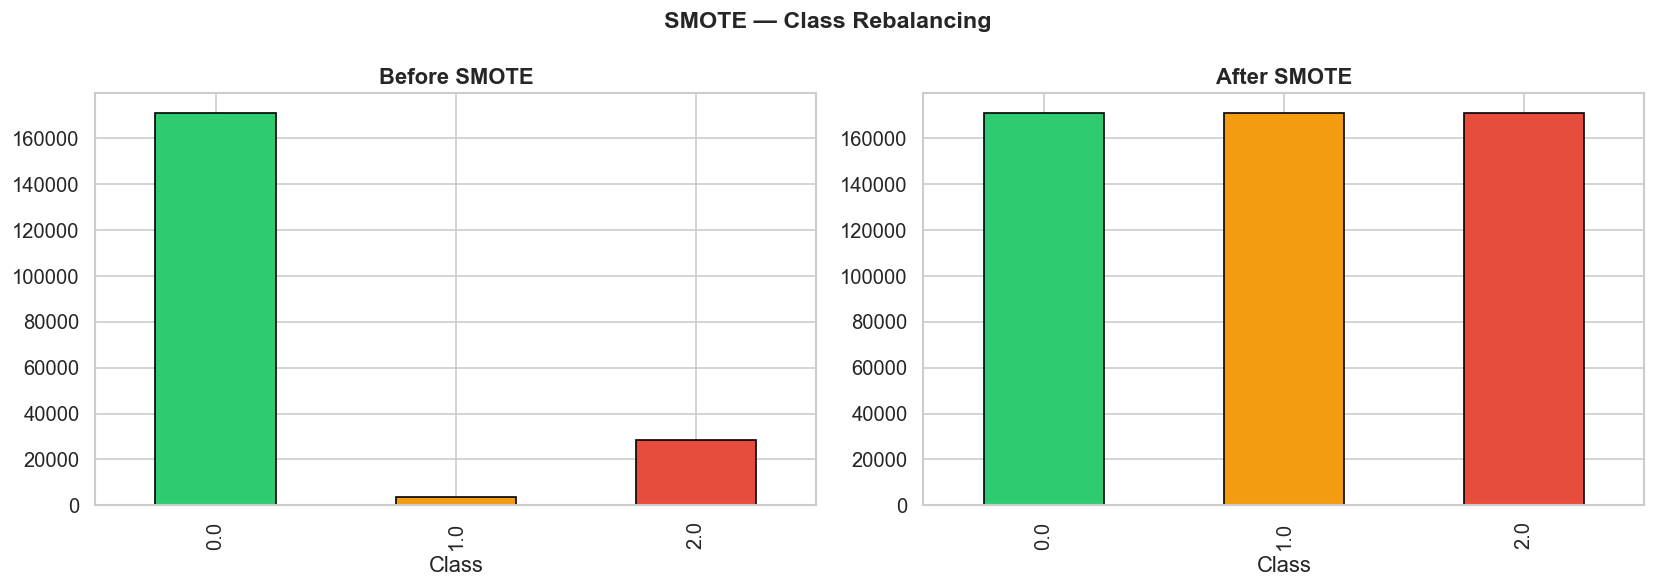

In [ ]:
smote = SMOTE(random_state=SEED, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set:  {len(y_train):,}")
print(f"After SMOTE:            {len(y_train_smote):,}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.Series(y_train).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_xlabel('Class')

pd.Series(y_train_smote).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_xlabel('Class')

plt.suptitle('SMOTE — Class Rebalancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 CTGAN (Conditional GAN)

In [ ]:
# We train CTGAN on the minority classes and generate synthetic samples
# to balance the dataset.

# Determine how many samples we need per minority class
majority_count = y_train.value_counts().max()
class_counts = y_train.value_counts().sort_index()

print("Target: balance all classes to", majority_count, "samples")
print("Current counts:", class_counts.to_dict())

# Prepare training data as a DataFrame for SDV
train_df = pd.DataFrame(X_train, columns=X.columns)
train_df['Diabetes_012'] = y_train.values

# CTGAN metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_df)

# Train CTGAN
print("\n⏳ Training CTGAN (this may take several minutes)...")
ctgan = CTGANSynthesizer(
    metadata,
    epochs=150,
    batch_size=500,
    verbose=False
)
ctgan.fit(train_df)
print("✅ CTGAN training complete.")

In [ ]:
# Generate synthetic data for minority classes
synthetic_dfs = []

for cls in [1, 2]:
    needed = majority_count - class_counts[cls]
    if needed <= 0:
        continue

    # Generate with condition
    condition_df = ctgan.sample(num_rows=needed)
    # Filter/force to desired class
    condition_df['Diabetes_012'] = cls
    synthetic_dfs.append(condition_df)
    print(f"Generated {needed:,} synthetic samples for Class {cls} ({class_map[cls]})")

synthetic_ctgan = pd.concat(synthetic_dfs, ignore_index=True)

# Combine with original training data
train_ctgan_full = pd.concat([train_df, synthetic_ctgan], ignore_index=True)
X_train_ctgan = scaler.transform(train_ctgan_full.drop('Diabetes_012', axis=1))
y_train_ctgan = train_ctgan_full['Diabetes_012'].values

print(f"\nCTGAN augmented training set: {len(y_train_ctgan):,}")
print("Class distribution:")
print(pd.Series(y_train_ctgan).value_counts().sort_index().to_string())

### 3.3 Variational Autoencoder (VAE)

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=16):
        super(VAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss


def train_vae(X_data, epochs=100, batch_size=256, lr=1e-3):
    input_dim = X_data.shape[1]
    model = VAE(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    dataset = TensorDataset(torch.FloatTensor(X_data))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            optimizer.zero_grad()
            recon, mu, logvar = model(batch)
            loss = vae_loss(recon, batch, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 25 == 0:
            print(f"  Epoch {epoch+1}/{epochs} — Loss: {total_loss / len(X_data):.4f}")

    return model


def generate_vae_samples(model, n_samples, input_dim, latent_dim=16):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim)
        samples = model.decode(z).numpy()
    return samples

print("VAE architecture defined. ✅")

In [ ]:
# Train separate VAEs per minority class and generate synthetic samples

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
y_train_arr = y_train.values

synthetic_vae_list = []

for cls in [1, 2]:
    needed = majority_count - class_counts[cls]
    if needed <= 0:
        continue

    print(f"\n--- Training VAE for Class {cls} ({class_map[cls]}) ---")
    cls_data = X_train_df[y_train_arr == cls].values

    vae_model = train_vae(cls_data, epochs=100, batch_size=256, lr=1e-3)
    synthetic_samples = generate_vae_samples(vae_model, needed, cls_data.shape[1])

    syn_df = pd.DataFrame(synthetic_samples, columns=X.columns)
    syn_df['Diabetes_012'] = cls
    synthetic_vae_list.append(syn_df)
    print(f"  Generated {needed:,} synthetic samples for Class {cls}")

synthetic_vae = pd.concat(synthetic_vae_list, ignore_index=True)

# Build augmented training set (note: VAE operates on scaled data)
train_vae_X = np.vstack([X_train_scaled, synthetic_vae.drop('Diabetes_012', axis=1).values])
train_vae_y = np.concatenate([y_train.values, synthetic_vae['Diabetes_012'].values])

print(f"\nVAE augmented training set: {len(train_vae_y):,}")
print("Class distribution:")
print(pd.Series(train_vae_y).astype(int).value_counts().sort_index().to_string())

---
# ΜΕΡΟΣ 4 — Εκπαίδευση Μοντέλων σε Επαυξημένα Δεδομένα & Σύγκριση
---

### 4.1 Εκπαίδευση Μοντέλων σε Δεδομένα Επαυξημένα με SMOTE

In [ ]:
# ── Random Forest + SMOTE ───────────────────────────────────
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=SEED, n_jobs=-1)
rf_smote_res, rf_smote_pred, rf_smote_proba, _ = evaluate_model(
    rf_smote, X_train_smote, y_train_smote, X_test_scaled, y_test, 'RF_SMOTE')

print("=== Random Forest + SMOTE ===")
print(classification_report(y_test, rf_smote_pred, target_names=[class_map[i] for i in [0,1,2]], zero_division=0))
plot_confusion_matrix(y_test, rf_smote_pred, 'RF + SMOTE — Confusion Matrix')

# ── XGBoost + SMOTE ───────────────────────────────────────
xgb_smote = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           random_state=SEED, use_label_encoder=False,
                           eval_metric='mlogloss', n_jobs=-1)
xgb_smote_res, xgb_smote_pred, xgb_smote_proba, _ = evaluate_model(
    xgb_smote, X_train_smote, y_train_smote, X_test_scaled, y_test, 'XGB_SMOTE')

print("\n=== XGBoost + SMOTE ===")
print(classification_report(y_test, xgb_smote_pred, target_names=[class_map[i] for i in [0,1,2]], zero_division=0))
plot_confusion_matrix(y_test, xgb_smote_pred, 'XGB + SMOTE — Confusion Matrix')

### 4.2 Εκπαίδευση Μοντέλων σε Δεδομένα Επαυξημένα με CTGAN

In [ ]:
# ── Random Forest + CTGAN ──────────────────────────────────
rf_ctgan = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=SEED, n_jobs=-1)
rf_ctgan_res, rf_ctgan_pred, rf_ctgan_proba, _ = evaluate_model(
    rf_ctgan, X_train_ctgan, y_train_ctgan, X_test_scaled, y_test, 'RF_CTGAN')

print("=== Random Forest + CTGAN ===")
print(classification_report(y_test, rf_ctgan_pred, target_names=[class_map[i] for i in [0,1,2]], zero_division=0))
plot_confusion_matrix(y_test, rf_ctgan_pred, 'RF + CTGAN — Confusion Matrix')

# ── XGBoost + CTGAN ──────────────────────────────────────
xgb_ctgan = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           random_state=SEED, use_label_encoder=False,
                           eval_metric='mlogloss', n_jobs=-1)
xgb_ctgan_res, xgb_ctgan_pred, xgb_ctgan_proba, _ = evaluate_model(
    xgb_ctgan, X_train_ctgan, y_train_ctgan, X_test_scaled, y_test, 'XGB_CTGAN')

print("\n=== XGBoost + CTGAN ===")
print(classification_report(y_test, xgb_ctgan_pred, target_names=[class_map[i] for i in [0,1,2]], zero_division=0))
plot_confusion_matrix(y_test, xgb_ctgan_pred, 'XGB + CTGAN — Confusion Matrix')

### 4.3 Εκπαίδευση Μοντέλων σε Δεδομένα Επαυξημένα με VAE

In [ ]:
# ── Random Forest + VAE ────────────────────────────────────
rf_vae = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=SEED, n_jobs=-1)
rf_vae_res, rf_vae_pred, rf_vae_proba, _ = evaluate_model(
    rf_vae, train_vae_X, train_vae_y, X_test_scaled, y_test, 'RF_VAE')

print("=== Random Forest + VAE ===")
print(classification_report(y_test, rf_vae_pred, target_names=[class_map[i] for i in [0,1,2]], zero_division=0))
plot_confusion_matrix(y_test, rf_vae_pred, 'RF + VAE — Confusion Matrix')

# ── XGBoost + VAE ────────────────────────────────────────
xgb_vae = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                         random_state=SEED, use_label_encoder=False,
                         eval_metric='mlogloss', n_jobs=-1)
xgb_vae_res, xgb_vae_pred, xgb_vae_proba, _ = evaluate_model(
    xgb_vae, train_vae_X, train_vae_y, X_test_scaled, y_test, 'XGB_VAE')

print("\n=== XGBoost + VAE ===")
print(classification_report(y_test, xgb_vae_pred, target_names=[class_map[i] for i in [0,1,2]], zero_division=0))
plot_confusion_matrix(y_test, xgb_vae_pred, 'XGB + VAE — Confusion Matrix')

### 4.4 Συνολική Σύγκριση Αποτελεσμάτων

In [ ]:
all_results = pd.DataFrame([
    rf_results, xgb_results,
    rf_smote_res, xgb_smote_res,
    rf_ctgan_res, xgb_ctgan_res,
    rf_vae_res, xgb_vae_res
]).set_index('Model')

print("="*90)
print("  FULL COMPARISON TABLE")
print("="*90)
all_results.round(4)

In [ ]:
# ── Visual comparison: F1 macro ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# F1 Macro
metrics = ['F1_macro', 'Precision_macro', 'Recall_macro']
titles = ['F1-Score (Macro)', 'Precision (Macro)', 'Recall (Macro)']

for ax, metric, title in zip(axes, metrics, titles):
    vals = all_results[metric]
    colors = ['#95a5a6'] * 2 + ['#3498db'] * 2 + ['#9b59b6'] * 2 + ['#e67e22'] * 2
    bars = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals.values) * 1.15)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.3f}', ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Per-class F1 comparison ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, cls in enumerate([0, 1, 2]):
    col = f'F1_class{cls}'
    vals = all_results[col]
    colors = ['#95a5a6'] * 2 + ['#3498db'] * 2 + ['#9b59b6'] * 2 + ['#e67e22'] * 2
    bars = axes[i].bar(range(len(vals)), vals.values, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'F1-Score — Class {cls} ({class_map[cls]})', fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, max(vals.values) * 1.2 if max(vals.values) > 0 else 1)
    for b in bars:
        axes[i].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                     f'{b.get_height():.3f}', ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Per-Class F1-Score Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── AUC-ROC comparison ─────────────────────────────────────
auc_vals = all_results['AUC_ROC_ovr']
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#95a5a6'] * 2 + ['#3498db'] * 2 + ['#9b59b6'] * 2 + ['#e67e22'] * 2
bars = ax.bar(range(len(auc_vals)), auc_vals.values, color=colors, edgecolor='black')
ax.set_xticks(range(len(auc_vals)))
ax.set_xticklabels(auc_vals.index, rotation=45, ha='right')
ax.set_title('AUC-ROC (One-vs-Rest, Macro) Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0.5, max(auc_vals.values) * 1.05)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
            f'{b.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

---
# ΜΕΡΟΣ 5 — Αξιολόγηση Ποιότητας Συνθετικών Δεδομένων
---

### 5.1 Έλεγχος Kolmogorov–Smirnov (KS)

In [ ]:
# Compare distributions of each feature: Original vs. Synthetic
# We compare the training data for each minority class

def ks_test_comparison(original_df, synthetic_df, feature_cols, label='CTGAN'):
    """Run KS test for each feature between original and synthetic data."""
    results = []
    for feat in feature_cols:
        stat, pval = ks_2samp(original_df[feat].values, synthetic_df[feat].values)
        results.append({'Feature': feat, 'KS_Statistic': stat, 'p_value': pval,
                        'Same_Distribution': 'Yes' if pval > 0.05 else 'No'})
    return pd.DataFrame(results)

feature_cols = X.columns.tolist()

# CTGAN KS test (Class 1)
orig_cls1 = train_df[train_df['Diabetes_012'] == 1][feature_cols]
syn_ctgan_cls1 = synthetic_ctgan[synthetic_ctgan['Diabetes_012'] == 1][feature_cols]

print("="*70)
print("  KS Test: Original vs. CTGAN Synthetic (Class 1 — Prediabetes)")
print("="*70)
ks_ctgan = ks_test_comparison(orig_cls1, syn_ctgan_cls1, feature_cols, 'CTGAN')
print(ks_ctgan.to_string(index=False))
print(f"\nFeatures with same distribution: {(ks_ctgan['Same_Distribution'] == 'Yes').sum()} / {len(feature_cols)}")

In [ ]:
# VAE KS test (Class 1, on scaled data)
orig_cls1_scaled = X_train_df[y_train_arr == 1]
syn_vae_cls1 = synthetic_vae[synthetic_vae['Diabetes_012'] == 1][feature_cols]

print("="*70)
print("  KS Test: Original vs. VAE Synthetic (Class 1 — Prediabetes)")
print("="*70)
ks_vae = ks_test_comparison(orig_cls1_scaled, syn_vae_cls1, feature_cols, 'VAE')
print(ks_vae.to_string(index=False))
print(f"\nFeatures with same distribution: {(ks_vae['Same_Distribution'] == 'Yes').sum()} / {len(feature_cols)}")

In [ ]:
# Summary bar chart
fig, ax = plt.subplots(figsize=(10, 5))
methods = ['CTGAN', 'VAE']
same_dist = [
    (ks_ctgan['Same_Distribution'] == 'Yes').sum(),
    (ks_vae['Same_Distribution'] == 'Yes').sum(),
]
diff_dist = [len(feature_cols) - s for s in same_dist]

x = np.arange(len(methods))
ax.bar(x - 0.15, same_dist, 0.3, label='Same Distribution (p > 0.05)', color='#2ecc71', edgecolor='black')
ax.bar(x + 0.15, diff_dist, 0.3, label='Different Distribution (p ≤ 0.05)', color='#e74c3c', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=12)
ax.set_ylabel('Number of Features')
ax.set_title('KS Test Results: Feature Distribution Preservation', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Οπτικοποίηση t-SNE

In [ ]:
# t-SNE on a sample for computational feasibility
SAMPLE_SIZE = 5000

# Sample from each source
np.random.seed(SEED)

# Original data
orig_sample_idx = np.random.choice(len(X_train_scaled), min(SAMPLE_SIZE, len(X_train_scaled)), replace=False)
orig_sample = X_train_scaled[orig_sample_idx]
orig_labels = np.zeros(len(orig_sample))  # label 0 = Original

# SMOTE synthetic (the extra samples)
smote_extra = X_train_smote[len(X_train_scaled):]
smote_sample_idx = np.random.choice(len(smote_extra), min(SAMPLE_SIZE, len(smote_extra)), replace=False)
smote_sample = smote_extra[smote_sample_idx]
smote_labels = np.ones(len(smote_sample))  # label 1 = SMOTE

# CTGAN synthetic
ctgan_syn_data = scaler.transform(synthetic_ctgan[feature_cols].values)
ctgan_sample_idx = np.random.choice(len(ctgan_syn_data), min(SAMPLE_SIZE, len(ctgan_syn_data)), replace=False)
ctgan_sample = ctgan_syn_data[ctgan_sample_idx]
ctgan_labels = np.full(len(ctgan_sample), 2)  # label 2 = CTGAN

# VAE synthetic
vae_syn_data = synthetic_vae[feature_cols].values  # already scaled
vae_sample_idx = np.random.choice(len(vae_syn_data), min(SAMPLE_SIZE, len(vae_syn_data)), replace=False)
vae_sample = vae_syn_data[vae_sample_idx]
vae_labels = np.full(len(vae_sample), 3)  # label 3 = VAE

# Combine
combined = np.vstack([orig_sample, smote_sample, ctgan_sample, vae_sample])
combined_labels = np.concatenate([orig_labels, smote_labels, ctgan_labels, vae_labels])

print(f"Running t-SNE on {len(combined):,} samples...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(combined)
print("✅ t-SNE complete.")

In [ ]:
# Plot t-SNE
fig, ax = plt.subplots(figsize=(12, 8))

source_names = {0: 'Original', 1: 'SMOTE', 2: 'CTGAN', 3: 'VAE'}
source_colors = {0: '#2c3e50', 1: '#3498db', 2: '#9b59b6', 3: '#e67e22'}

for src in [0, 1, 2, 3]:
    mask = combined_labels == src
    ax.scatter(tsne_results[mask, 0], tsne_results[mask, 1],
               c=source_colors[src], label=source_names[src],
               alpha=0.4, s=8)

ax.set_title('t-SNE: Original vs. Synthetic Data Distributions', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.legend(markerscale=5, fontsize=11)
plt.tight_layout()
plt.show()

---
# ΜΕΡΟΣ 6 — Τελική Σύνοψη & Συμπεράσματα
---

In [ ]:
# ── Final comparison table ─────────────────────────────────
print("\n" + "="*90)
print("  FINAL PERFORMANCE COMPARISON — ALL MODELS")
print("="*90 + "\n")

summary_cols = ['F1_macro', 'F1_class0', 'F1_class1', 'F1_class2',
                'Precision_macro', 'Recall_macro', 'AUC_ROC_ovr']

final_table = all_results[summary_cols].round(4)
final_table.columns = ['F1 (Macro)', 'F1 (NoD)', 'F1 (PreD)', 'F1 (Diab)',
                        'Precision', 'Recall', 'AUC-ROC']
print(final_table.to_string())

print("\n\nKey Observations:")
print("-" * 50)
best_f1_macro = all_results['F1_macro'].idxmax()
best_f1_cls1 = all_results['F1_class1'].idxmax()
best_auc = all_results['AUC_ROC_ovr'].idxmax()

print(f"  • Best F1 (Macro):       {best_f1_macro} → {all_results.loc[best_f1_macro, 'F1_macro']:.4f}")
print(f"  • Best F1 (Prediabetes): {best_f1_cls1} → {all_results.loc[best_f1_cls1, 'F1_class1']:.4f}")
print(f"  • Best AUC-ROC:          {best_auc} → {all_results.loc[best_auc, 'AUC_ROC_ovr']:.4f}")

In [ ]:
# ── Improvement heatmap ────────────────────────────────────
# Show improvement of each augmented model over its respective baseline

improvement_data = {}
for augmented, baseline in [('RF_SMOTE', 'RF_Baseline'), ('XGB_SMOTE', 'XGB_Baseline'),
                             ('RF_CTGAN', 'RF_Baseline'), ('XGB_CTGAN', 'XGB_Baseline'),
                             ('RF_VAE', 'RF_Baseline'), ('XGB_VAE', 'XGB_Baseline')]:
    improvement_data[augmented] = all_results.loc[augmented, summary_cols] - all_results.loc[baseline, summary_cols]

improvement_df = pd.DataFrame(improvement_data).T
improvement_df.columns = ['F1 (Macro)', 'F1 (NoD)', 'F1 (PreD)', 'F1 (Diab)',
                           'Precision', 'Recall', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(improvement_df, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Improvement over Baseline (Δ)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nPositive values (green) = improvement over baseline")
print("Negative values (red) = decrease from baseline")

---
## Συμπεράσματα

1. Η **ανισορροπία κλάσεων** είναι έντονη στο dataset BRFSS, με τον προ-διαβήτη (Κλάση 1) να είναι σοβαρά υποεκπροσωπημένος.

2. Το **SMOTE** παρέχει μια απλή και γρήγορη επαύξηση baseline που συνήθως βελτιώνει την ανάκληση της μειοψηφικής κλάσης.

3. Το **CTGAN** μαθαίνει την κατανομή των δεδομένων και μπορεί να παράγει πιο ρεαλιστικά συνθετικά δείγματα, διατηρώντας καλύτερα τις συσχετίσεις μεταξύ features.

4. Το **VAE** προσφέρει μια άλλη γεννητική προσέγγιση βαθιάς μάθησης που μπορεί να παράγει πιο ομαλές παρεμβολές στον χώρο των features.

5. Ο **έλεγχος KS** και οι **οπτικοποιήσεις t-SNE** βοηθούν στην αξιολόγηση του πόσο καλά κάθε μέθοδος διατηρεί τις στατιστικές ιδιότητες των πρωτότυπων δεδομένων.

6. Η τελική επιλογή μοντέλου πρέπει να λαμβάνει υπόψη την **ισορροπία μεταξύ συνολικής ακρίβειας και απόδοσης στις μειοψηφικές κλάσεις**.

---
*Εργασία Ανάλυσης Βιο-Δεδομένων — Ομάδα 3*